In [1]:
import os
import sys

import numpy as np
import math
import uproot as uproot
import pickle
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import gridspec

# Add the head direcoty to sys.path
workspace_root = "/exp/sbnd/app/users/amoor/cafpyana/cafpyana/analysis_village/sample_validations/202503"  
sys.path.insert(0, workspace_root + "/../../../")

# import this repo's classes
import pyanalib.pandas_helpers as ph
from makedf.util import *
import pyanalib.pandas_helpers as ph
import pyanalib.split_df_helpers as splh
import pyanalib.stat_helpers as sh

In [2]:
#get sample file paths
#need four for the analysis standard: data (BNB + fixed light dev, intime cosmic), mc (BNB + light, low + threshold BNB + light) 

#input_path = "/exp/sbnd/data/users/amoor/cafpyana_samples/2025Cb/"
input_path = "/exp/sbnd/data/users/apapadop/dfs/v10_14_00/"
#mc_file = input_path + "mc_2025B_Oct25_afm.df"        #mc BNB + light?
#data_file = input_path + "data_2025B_Oct25_afm.df"    #data BNB + fixed light

#mc_bnb_cosmic_file = input_path + "list_mc_MCP2025C_FallValidationII_prodgenie_corsika_proton_rockbox0p1_sbnd_CV_caf_flat_caf_sbnd_sungbin_afm_Dec25b.df"
##mc_rockbox_dirt_file = input_path + "mc_MCP2025B_prodgenie_corsika_proton_rockbox_lowenergydirt_sbnd_CV_caf_flat_caf_sbnd_sungbin_afm_Nov25.df"
#data_offbeam_light_file = input_path + "list_data_MCP2025C_FallValidationII_RollingDev_offbeamlight_v10_14_00_flatcaf_sbnd_afm_Dec25b.df"
#data_bnb_light_dev_file = input_path + "list_data_MCP2025C_FallValidationII_RollingDev_bnblight_v10_14_00_flatcaf_sbnd_afm_Dec25b.df"

mc_bnb_cosmic_file = "/exp/sbnd/data/users/sungbino/dfs/v10_14_00/mc_MCP2025C_FallValidationII_prodgenie_corsika_proton_rockbox0p1_sbnd_CV_caf_flat_caf_sbnd_general_dfs.df"
data_offbeam_light_file = input_path + "data_MCP2025C_FallValidationII_RollingDev_offbeamlight_v10_14_00_flatcaf_sbnd.df"
data_bnb_light_dev_file = input_path + "data_MCP2025C_FallValidationII_RollingDev_bnblight_v10_14_00_flatcaf_sbnd.df"

In [3]:
sample_str = "v10_14_00"

In [4]:
## Check keys in each file
print("keys in mc_bnb_cosmic_file")
splh.print_keys(mc_bnb_cosmic_file)

print("keys in data_offbeam_light_file")
splh.print_keys(data_offbeam_light_file)

print("keys in data_bnb_light_dev_file")
splh.print_keys(data_bnb_light_dev_file)

keys in mc_bnb_cosmic_file
Keys: ['/evt_0', '/evt_1', '/evt_10', '/evt_11', '/evt_12', '/evt_13', '/evt_14', '/evt_15', '/evt_16', '/evt_17', '/evt_18', '/evt_19', '/evt_2', '/evt_20', '/evt_21', '/evt_3', '/evt_4', '/evt_5', '/evt_6', '/evt_7', '/evt_8', '/evt_9', '/hdr_0', '/hdr_1', '/hdr_10', '/hdr_11', '/hdr_12', '/hdr_13', '/hdr_14', '/hdr_15', '/hdr_16', '/hdr_17', '/hdr_18', '/hdr_19', '/hdr_2', '/hdr_20', '/hdr_21', '/hdr_3', '/hdr_4', '/hdr_5', '/hdr_6', '/hdr_7', '/hdr_8', '/hdr_9', '/histpotdf_0', '/histpotdf_1', '/histpotdf_10', '/histpotdf_11', '/histpotdf_12', '/histpotdf_13', '/histpotdf_14', '/histpotdf_15', '/histpotdf_16', '/histpotdf_17', '/histpotdf_18', '/histpotdf_19', '/histpotdf_2', '/histpotdf_20', '/histpotdf_21', '/histpotdf_3', '/histpotdf_4', '/histpotdf_5', '/histpotdf_6', '/histpotdf_7', '/histpotdf_8', '/histpotdf_9', '/mcnu_0', '/mcnu_1', '/mcnu_10', '/mcnu_11', '/mcnu_12', '/mcnu_13', '/mcnu_14', '/mcnu_15', '/mcnu_16', '/mcnu_17', '/mcnu_18', '/mcnu_1

In [5]:
## Check split multiplicity
print("mc_bnb_cosmic_file n_split: %d" %splh.get_n_split(mc_bnb_cosmic_file))
#print("mc_rockbox_dirt_file n_split: %d" %splh.get_n_split(mc_rockbox_dirt_file))
print("data_offbeam_light_file n_split: %d" %splh.get_n_split(data_offbeam_light_file))
print("data_bnb_light_dev_file n_split: %d" %splh.get_n_split(data_bnb_light_dev_file))

mc_bnb_cosmic_file n_split: 22
data_offbeam_light_file n_split: 2
data_bnb_light_dev_file n_split: 4


In [6]:
## Define keys to load
n_max_concat = 4 ## for big files, each key would have more than one split
keys2load = ['opflash', 'hdr', 'pot', 'evt', 'mcnu']

## Load DataFrames
mc_bnb_cosmic_dfs = splh.load_dfs(mc_bnb_cosmic_file, keys2load, n_max_concat)
#mc_rockbox_dirt_dfs = splh.load_dfs(mc_rockbox_dirt_file, keys2load, n_max_concat)
data_offbeam_light_dfs = splh.load_dfs(data_offbeam_light_file, keys2load, n_max_concat)
data_bnb_light_dfs = splh.load_dfs(data_bnb_light_dev_file, keys2load, n_max_concat)

In [7]:
data_offbeam_light_dfs["evt"].columns.values

array([('slc', 'barycenterFM', 'chargeTotal', '', '', ''),
       ('slc', 'barycenterFM', 'flashTime', '', '', ''),
       ('slc', 'barycenterFM', 'flashPEs', '', '', ''),
       ('slc', 'barycenterFM', 'chi2', '', '', ''),
       ('slc', 'barycenterFM', 'score', '', '', ''),
       ('slc', 'barycenterFM', 'deltaZ', '', '', ''),
       ('slc', 'is_clear_cosmic', '', '', '', ''),
       ('slc', 'vertex', 'x', '', '', ''),
       ('slc', 'vertex', 'y', '', '', ''),
       ('slc', 'vertex', 'z', '', '', ''),
       ('slc', 'self', '', '', '', ''),
       ('slc', 'tmatch', 'eff', '', '', ''),
       ('slc', 'tmatch', 'pur', '', '', ''),
       ('slc', 'tmatch', 'idx', '', '', ''),
       ('slc', 'producer', '', '', '', ''),
       ('slc', 'nuid', 'crlongtrkdiry', '', '', ''),
       ('slc', 'nu_score', '', '', '', ''),
       ('slc', 'opt0', 'score', '', '', ''),
       ('slc', 'opt0', 'time', '', '', ''),
       ('slc', 'opt0', 'measPE', '', '', ''),
       ('slc', 'opt0', 'hypoPE', '', '

## Check for duplication

In [8]:
def find_duplicate_run_evt_combinations(df):
    """
    Given a DataFrame with a MultiIndex of (__ntuple, entry), find all rows
    where (run, evt) combinations are duplicated.

    Parameters:
        df (pd.DataFrame): Input DataFrame with MultiIndex and columns 'run' and 'evt'.

    Returns:
        pd.DataFrame: Filtered DataFrame containing only duplicated (run, evt) combinations,
                      including the original (__ntuple, entry) indices.
    """
    # Reset index to access MultiIndex as columns
    df_reset = df.reset_index()

    # Find duplicated (run, evt) combinations
    dup_mask = df_reset.duplicated(subset=['run', 'subrun', 'evt'], keep=False)

    # Extract duplicates
    duplicates = df_reset[dup_mask]

    # Sort for readability
    duplicates_sorted = duplicates.sort_values(by=['run', 'subrun', 'evt'])

    #return duplicates_sorted[['__ntuple', 'entry', 'run', 'subrun', 'evt']]

    print(duplicates_sorted[['__ntuple', 'entry', 'run', 'subrun', 'evt']])
    #return duplicates_sorted[['__ntuple', 'entry', 'run', 'subrun', 'evt']]

def plot_duplicate_run_subrun_evt_distribution(df, title=""):
    """
    Computes and plots the distribution of how many times each (run, subrun, evt) combination appears.

    Parameters:
        df (pd.DataFrame): Input DataFrame with MultiIndex (__ntuple, entry)
                           and columns including 'run', 'subrun', and 'evt'.
        title (str): Title for the plot (optional).
    
    Returns:
        pd.Series: Duplication count distribution 
                   (index = count, value = number of (run, subrun, evt) with that count)
    """
    # Reset index to work with columns
    df_reset = df.reset_index()

    # Count occurrences of each (run, subrun, evt)
    combo_counts = df_reset.groupby(['run', 'subrun', 'evt']).size()

    # Get distribution of these counts
    distribution = combo_counts.value_counts().sort_index()

    # Plotting
    plt.figure(figsize=(8, 5))
    distribution.plot(kind='bar', log=True)
    plt.xlabel('Number of times (run, subrun, evt) appears')
    plt.ylabel('Entries (spills)')
    plt.title(title)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def filter_unique_events(df):
    # If your index includes '__ntuple' and 'entry', reset to access them as columns
    df_reset = df.reset_index()

    # Find duplicated (run, subrun, evt) — keep=False marks *all* occurrences as duplicates
    dup_mask = df_reset.duplicated(subset=['run', 'subrun', 'evt'], keep=False)

    # Keep only rows that are NOT duplicated
    unique_df = df_reset[~dup_mask]

    # Optional: set index back if needed
    return unique_df.set_index(df.index.names)

def filter_using_hdr(df, hdrdf):
    allowed_keys = set(hdrdf.index)

    ntuples = df.index.get_level_values('__ntuple').to_numpy()
    entries = df.index.get_level_values('entry').to_numpy()
    keys = np.column_stack((ntuples, entries))

    # Create mask using list comprehension (faster than pure zip for large data)
    mask = [(nt, en) in allowed_keys for nt, en in keys]

    return df[mask]

In [9]:
print("duplication for MC BNB + Cosmic sample")
find_duplicate_run_evt_combinations(mc_bnb_cosmic_dfs["hdr"])

print("\n")
print("duplication for Off-beam + light sample")
find_duplicate_run_evt_combinations(data_offbeam_light_dfs["hdr"])

print("\n")
print("duplication for BNB + light sample")
find_duplicate_run_evt_combinations(data_bnb_light_dfs["hdr"])

duplication for MC BNB + Cosmic sample
       __ntuple  entry  run  subrun  evt
52387       123    336   57      60   40
59796       135    156   57      60   40
52389       123    338   57      60   43
59797       135    157   57      60   43
52390       123    339   57      60   46
59799       135    159   57      60   46
10275        70    370  310      68    1
60885       154    377  310      68    1
10279        70    374  310      68    8
60888       154    380  310      68    8
10281        70    376  310      68   17
60889       154    381  310      68   17
10282        70    377  310      68   18
60890       154    382  310      68   18
10283        70    378  310      68   22
60894       154    386  310      68   22
10286        70    381  310      68   31
60898       154    390  310      68   31
10291        70    386  310      68   49
60900       154    392  310      68   49


duplication for Off-beam + light sample
Empty DataFrame
Columns: [__ntuple, entry, run, subrun, ev

In [10]:
### Filter the hdr DataFrame first, then filter other DataFrames by matching with the hdr DataFrame
mc_bnb_cosmic_dfs["hdr"] = filter_unique_events(mc_bnb_cosmic_dfs["hdr"])
data_offbeam_light_dfs["hdr"] = filter_unique_events(data_offbeam_light_dfs["hdr"])
data_bnb_light_dfs["hdr"] = filter_unique_events(data_bnb_light_dfs["hdr"])

In [11]:
## Double check if it is filtered
find_duplicate_run_evt_combinations(mc_bnb_cosmic_dfs["hdr"])
find_duplicate_run_evt_combinations(data_offbeam_light_dfs["hdr"])
find_duplicate_run_evt_combinations(data_bnb_light_dfs["hdr"])

Empty DataFrame
Columns: [__ntuple, entry, run, subrun, evt]
Index: []
Empty DataFrame
Columns: [__ntuple, entry, run, subrun, evt]
Index: []
Empty DataFrame
Columns: [__ntuple, entry, run, subrun, evt]
Index: []


In [12]:
mc_bnb_cosmic_dfs["evt"] = filter_using_hdr(mc_bnb_cosmic_dfs["evt"], mc_bnb_cosmic_dfs["hdr"])
mc_bnb_cosmic_dfs["opflash"] = filter_using_hdr(mc_bnb_cosmic_dfs["opflash"], mc_bnb_cosmic_dfs["hdr"])
mc_bnb_cosmic_dfs["pot"] = filter_using_hdr(mc_bnb_cosmic_dfs["pot"], mc_bnb_cosmic_dfs["hdr"])
mc_bnb_cosmic_dfs["mcnu"] = filter_using_hdr(mc_bnb_cosmic_dfs["mcnu"], mc_bnb_cosmic_dfs["hdr"])

data_offbeam_light_dfs["evt"] = filter_using_hdr(data_offbeam_light_dfs["evt"], data_offbeam_light_dfs["hdr"])
data_offbeam_light_dfs["opflash"] = filter_using_hdr(data_offbeam_light_dfs["opflash"], data_offbeam_light_dfs["hdr"])
data_offbeam_light_dfs["pot"] = filter_using_hdr(data_offbeam_light_dfs["pot"], data_offbeam_light_dfs["hdr"])

data_bnb_light_dfs["evt"] = filter_using_hdr(data_bnb_light_dfs["evt"], data_bnb_light_dfs["hdr"])
data_bnb_light_dfs["opflash"] = filter_using_hdr(data_bnb_light_dfs["opflash"], data_bnb_light_dfs["hdr"])
data_bnb_light_dfs["pot"] = filter_using_hdr(data_bnb_light_dfs["pot"], data_bnb_light_dfs["hdr"])

## Normalisation

In [13]:
def get_n_evt(df):
    unique_count = df.index.droplevel(
        list(df.index.names[2:])  # drop everything except first two levels
    ).nunique()
    return unique_count

In [14]:
##remove these

## Collect the offbeam data fudge factor and scale for offbeam data
n_record_spill_data = get_n_evt(data_bnb_light_dfs['hdr'])
print("n_record_spill_data", n_record_spill_data)
n_gates_data =  len(data_bnb_light_dfs["pot"])
print("n_gates_data", n_gates_data)

n_record_spill_offbeam_data = get_n_evt(data_offbeam_light_dfs['hdr'])
print("n_record_spill_offbeam_data", n_record_spill_offbeam_data)
n_gates_offbeam_data = data_offbeam_light_dfs["hdr"][data_offbeam_light_dfs["hdr"]['first_in_subrun'] == 1]['noffbeambnb'].sum()
print("n_gates_offbeam_data", n_gates_offbeam_data)

p_trig_data = n_record_spill_data / n_gates_data
p_trig_offbeam_data = n_record_spill_offbeam_data / n_gates_offbeam_data

f_factor = (p_trig_data - p_trig_offbeam_data) / (1 - p_trig_offbeam_data)
print("f_factor: %f" %f_factor)

intime_gate_scale = (1. - f_factor) * (n_gates_data + 0.) / (n_gates_offbeam_data + 0.)
print("intime_gate_scale: %f" %intime_gate_scale)
intime_gate_scale = 0
print("intime_gate_scale: %f" %intime_gate_scale)

n_record_spill_data 63855
n_gates_data 709166
n_record_spill_offbeam_data 33080
n_gates_offbeam_data 0.0
f_factor: nan
intime_gate_scale: nan
intime_gate_scale: 0.000000


/tmp/ipykernel_1482/1901335783.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  p_trig_offbeam_data = n_record_spill_offbeam_data / n_gates_offbeam_data
/tmp/ipykernel_1482/1901335783.py:17: RuntimeWarning: invalid value encountered in scalar divide
  f_factor = (p_trig_data - p_trig_offbeam_data) / (1 - p_trig_offbeam_data)


In [15]:
## Collect pot scale for MC
mc_tot_pot = mc_bnb_cosmic_dfs["hdr"]['pot'].sum()
#n_evt_mc = get_n_evt(mc_bnb_cosmic_dfs["hdr"])

data_tot_pot = data_bnb_light_dfs["hdr"]['pot'].sum()
#data_tot_TOR860 = data_bnb_light_dfs["pot"]['TOR860'].sum()
#data_tot_TOR875 = data_bnb_light_dfs["pot"]['TOR875'].sum()

print("mc_tot_pot: %e" %(mc_tot_pot))
#print("n_evt_mc: %e" %(n_evt_mc))

print("data_tot_pot: %e" %(data_tot_pot))
#n_evt_data = get_n_evt(data_bnb_light_dfs["hdr"])
#print(n_evt_data)
#print("data_tot_TOR860: %e" %(data_tot_TOR860))
#print("data_tot_TOR875: %e" %(data_tot_TOR875))

target_pot = data_tot_pot
mc_pot_scale = target_pot / mc_tot_pot
#print(mc_pot_scale)
#print(mc_low_th_scale)
print("MC POT scale: %.3f" %(mc_pot_scale))

mc_tot_pot: 4.575711e+18
data_tot_pot: 3.279966e+18
MC POT scale: 0.717


In [16]:
## Comparison between observed and expected total number of recorded spills
n_evt_mc = get_n_evt(mc_bnb_cosmic_dfs["hdr"])

#intime_gate_scale = 1 #fudge for 0 POT

print("n_evt_data_onbeam: %d" %n_record_spill_data)
print("n_evt_exp.: %f" %(n_evt_mc * mc_pot_scale + n_record_spill_offbeam_data** intime_gate_scale))
print("- n_evt_mc: %f" %(n_evt_mc * mc_pot_scale))
print("- n_evt_data_offbeam: %f" %(n_record_spill_offbeam_data * intime_gate_scale))

n_evt_data_onbeam: 63855
n_evt_exp.: 60296.409694
- n_evt_mc: 60295.409694
- n_evt_data_offbeam: 0.000000


## OpFlash and light timing cut

In [17]:
def draw_a_distribution(df, col, title_x, x_min, x_max, nbins, title_y = "", is_logx = False, is_logy = False, label_top = ""):
    var = df[col]
    bins = np.logspace(np.log10(x_min), np.log10(x_max), nbins + 1) if is_logx else np.linspace(x_min, x_max, nbins + 1)
    bin_centers = np.sqrt(bins[:-1] * bins[1:]) if is_logx else 0.5 * (bins[:-1] + bins[1:])
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(var, bins, weights=[np.ones_like(data) * 1. for data in var], histtype="step", label=["all"])
    if is_logy:
        ax.yscale('log')
    ax.set_xlabel(title_x)
    ax.set_ylabel(title_y)
    ax.legend()
    ax.text(1.0, 1.02, label_top, transform=ax.transAxes, fontsize=14, fontweight='bold', ha='right') 
    plt.show()

def abs_comp_total_pe_two_mc_stack(
    df_mc, df_data_bnb_light, df_data_offbeam_light,
    col_mc, col_data, title_x, x_min, x_max, nbins,
    title_y = "", is_logx = False, is_logy = False, label_top = "",
    mc_scale = 1.533, intime_scale = 1.
):
    mc_var = df_mc[col_mc]
    data_bnb_light_var = df_data_bnb_light[col_data]
    data_offbeam_light_var = df_data_offbeam_light[col_data]

    # (kept for reference; override via intime_scale argument)
    #data_offbeam_light_scale = 0.103

    # Binning
    bins = (np.logspace(np.log10(x_min), np.log10(x_max), nbins + 1)
            if is_logx else np.linspace(x_min, x_max, nbins + 1))
    bin_centers = (np.sqrt(bins[:-1] * bins[1:])
                   if is_logx else 0.5 * (bins[:-1] + bins[1:]))
    bin_widths = np.diff(bins)

    fig, ax = plt.subplots(figsize=(8, 5))

    # --- Data histogram (BNB light) ---
    ax.hist(
        data_bnb_light_var, bins=bins,
        histtype="step", color="black", linewidth=2,
        label="BNB + light data"
    )

    # --- Components: compute binned counts ---
    mc_hist, _ = np.histogram(mc_var, bins=bins)
    offbeam_hist, _ = np.histogram(data_offbeam_light_var, bins=bins)

    # Apply scales
    mc_hist = mc_hist * mc_scale
    offbeam_hist = offbeam_hist

    # --- Stack components as bars (to show contributions) ---
    # Bottoms for stacking
    bottom0 = np.zeros_like(mc_hist, dtype=float)
    h1 = mc_hist
    h3 = offbeam_hist * intime_scale

    # Use bars so stack works in both linear and log-x; they also respect log-y.
    # (We avoid specifying colors explicitly so you can theme globally if you like.)
    ax.bar(bins[:-1], h1, width=bin_widths, align="edge",
           alpha=0.45, edgecolor="none", label="MC (BNB+cosmic)")
    ax.bar(bins[:-1], h3, width=bin_widths, align="edge",
           bottom=h1, alpha=0.45, edgecolor="none", label="Off-beam light")

    # --- Total prediction overlay (dashed step) ---
    pred_hist = h1 + h3
    ax.step(bin_centers, pred_hist, where="mid", linewidth=2, linestyle="--",
            label="Total prediction", color='red')

    # Scales, labels, cosmetics
    if is_logx:
        ax.set_xscale("log")
    if is_logy:
        ax.set_yscale("log")

    ax.set_xlabel(title_x)
    ax.set_ylabel(title_y if title_y else "Events")
    ax.set_xlim(x_min, x_max)

    # Legend: put data first, then components, then total
    # (Matplotlib collects in order added; this already matches that.)
    ax.legend(frameon=False)

    if label_top:
        ax.text(1.0, 1.02, label_top, transform=ax.transAxes,
                fontsize=14, fontweight='bold', ha='right')

    plt.tight_layout()
    plt.show()
    

In [18]:
mc_bnb_cosmic_opflash_df = mc_bnb_cosmic_dfs['opflash']
data_bnb_light_opflash_df = data_bnb_light_dfs['opflash']
data_offbeam_light_opflash_df = data_offbeam_light_dfs['opflash']

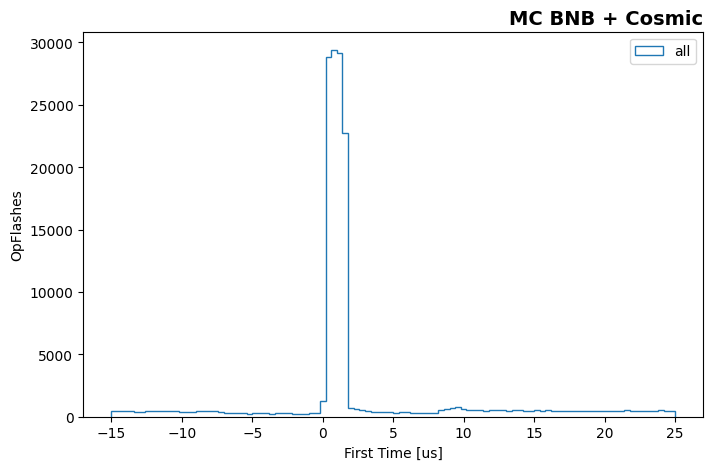

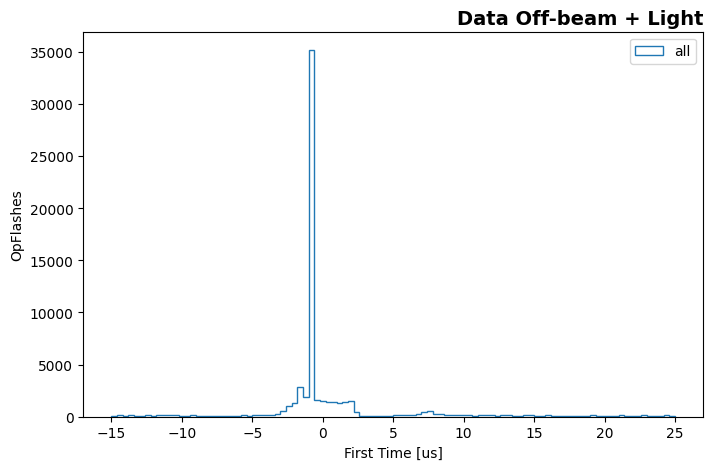

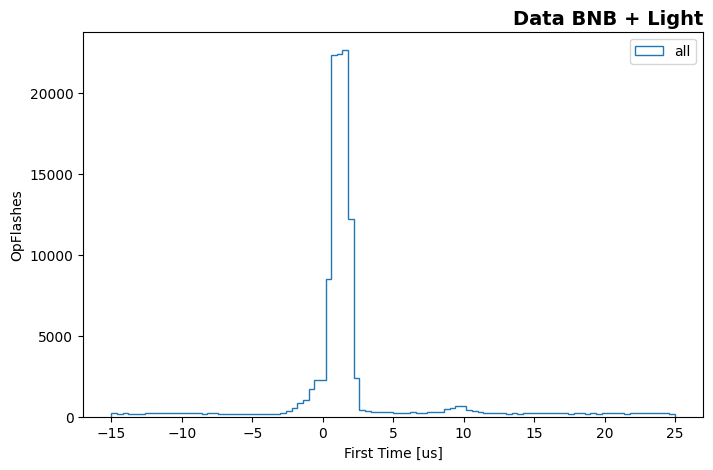

In [19]:
## Check OpFlash First Time distributions
draw_a_distribution(mc_bnb_cosmic_opflash_df, ('firsttime'), "First Time [us]", -15., 25., 100, "OpFlashes", False, False, "MC BNB + Cosmic")
draw_a_distribution(data_offbeam_light_opflash_df, ('firsttime'), "First Time [us]", -15., 25., 100, "OpFlashes", False, False, "Data Off-beam + Light")
draw_a_distribution(data_bnb_light_opflash_df, ('firsttime'), "First Time [us]", -15., 25., 100, "OpFlashes", False, False, "Data BNB + Light")

In [20]:
## Based on the previous block's result, we use [-5 us, +5 us] window for collecting OpFlashes corresponding to the trigger

mc_bnb_light_opflash_time_cut_df = mc_bnb_cosmic_opflash_df[(mc_bnb_cosmic_opflash_df.firsttime > -5.) & (mc_bnb_cosmic_opflash_df.firsttime < 5.)]
data_offbeam_light_opflash_df = data_offbeam_light_opflash_df[(data_offbeam_light_opflash_df.firsttime > -5.) & (data_offbeam_light_opflash_df.firsttime < 5.)]
data_bnb_light_opflash_df = data_bnb_light_opflash_df[(data_bnb_light_opflash_df.firsttime > -5.) & (data_bnb_light_opflash_df.firsttime < 5.)]

In [21]:
## Sum PEs for OpFlashes within the timing window

mc_bnb_cosmic_totalpe_sum_time_cut=(mc_bnb_light_opflash_time_cut_df.groupby(level=[0, 1])["totalpe"].sum())
data_offbeam_light_totalpe_sum_time_cut=(data_offbeam_light_opflash_df.groupby(level=[0, 1])["totalpe"].sum())
data_bnb_light_totalpe_sum_time_cut=(data_bnb_light_opflash_df.groupby(level=[0, 1])["totalpe"].sum())

In [22]:
## Add the total PE column to the hdr DataFrames, and fill empty (NaN) entries with 0.

mc_bnb_cosmic_dfs['hdr']['totalpe_timecut'] = mc_bnb_cosmic_totalpe_sum_time_cut
mc_bnb_cosmic_dfs['hdr']['totalpe_timecut'] = (mc_bnb_cosmic_dfs['hdr']['totalpe_timecut'].fillna(-1.))

data_offbeam_light_dfs['hdr']['totalpe_timecut'] = data_offbeam_light_totalpe_sum_time_cut
data_offbeam_light_dfs['hdr']['totalpe_timecut'] = (data_offbeam_light_dfs['hdr']['totalpe_timecut'].fillna(-1.))

data_bnb_light_dfs['hdr']['totalpe_timecut'] = data_bnb_light_totalpe_sum_time_cut
data_bnb_light_dfs['hdr']['totalpe_timecut'] = (data_bnb_light_dfs['hdr']['totalpe_timecut'].fillna(-1.))

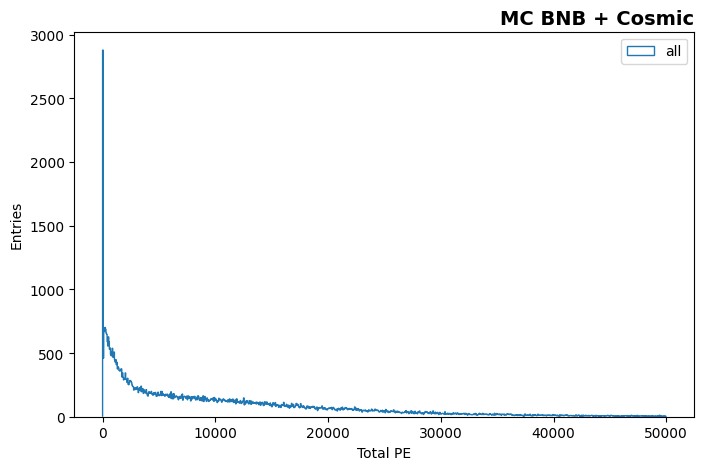

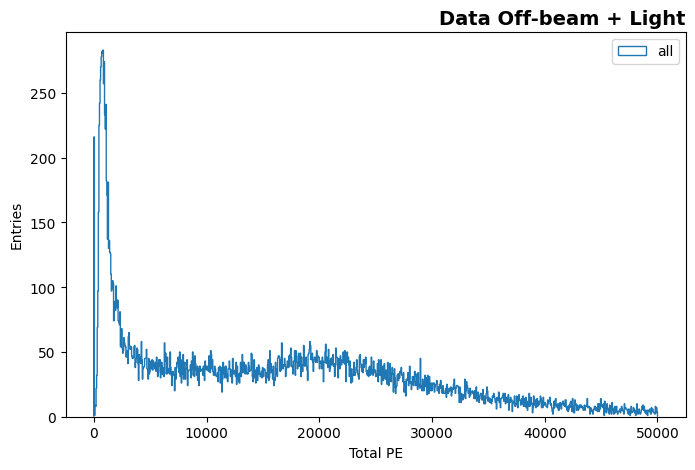

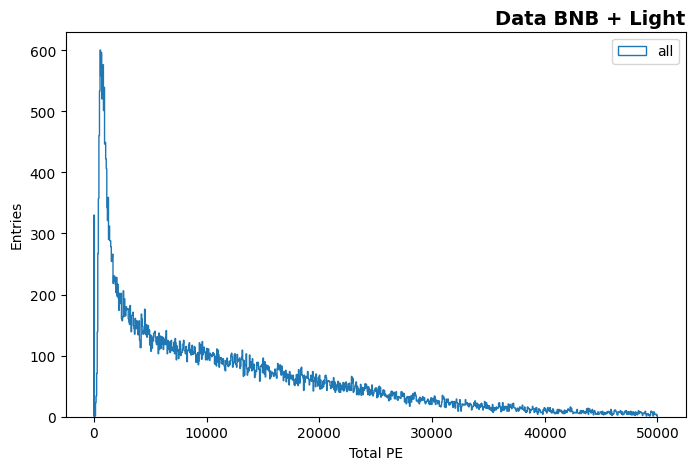

In [23]:
## Check the total PE distributions

draw_a_distribution(mc_bnb_cosmic_dfs['hdr'], ('totalpe_timecut'), "Total PE", -10, 50000, 1000, "Entries", False, False, "MC BNB + Cosmic")
draw_a_distribution(data_offbeam_light_dfs['hdr'], ('totalpe_timecut'), "Total PE", -10, 50000, 1000, "Entries", False, False, "Data Off-beam + Light")
draw_a_distribution(data_bnb_light_dfs['hdr'], ('totalpe_timecut'), "Total PE", -10, 50000, 1000, "Entries", False, False, "Data BNB + Light")

In [24]:
## Apply a scale to MC total PE
mc_bnb_cosmic_hdr_df = mc_bnb_cosmic_dfs['hdr']
#mc_bnb_cosmic_hdr_df['totalpe_timecut_0p66'] = mc_bnb_cosmic_hdr_df['totalpe_timecut'] * 0.66

data_offbeam_light_hdr_df = data_offbeam_light_dfs['hdr']
data_bnb_light_hdr_df = data_bnb_light_dfs['hdr']

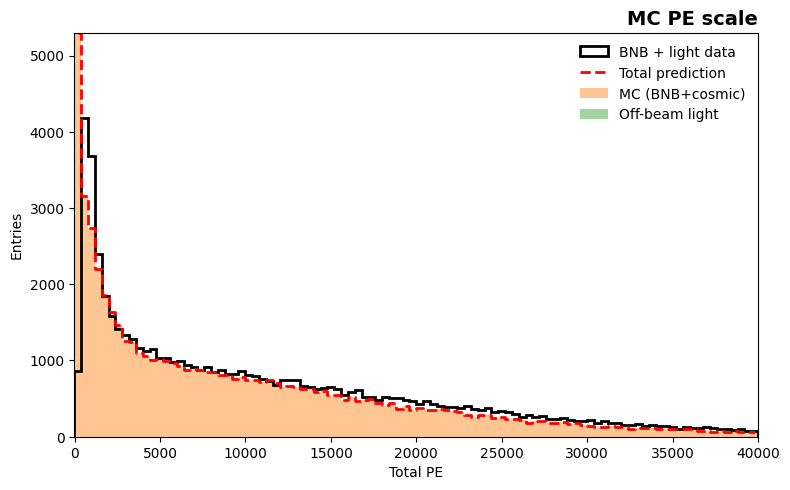

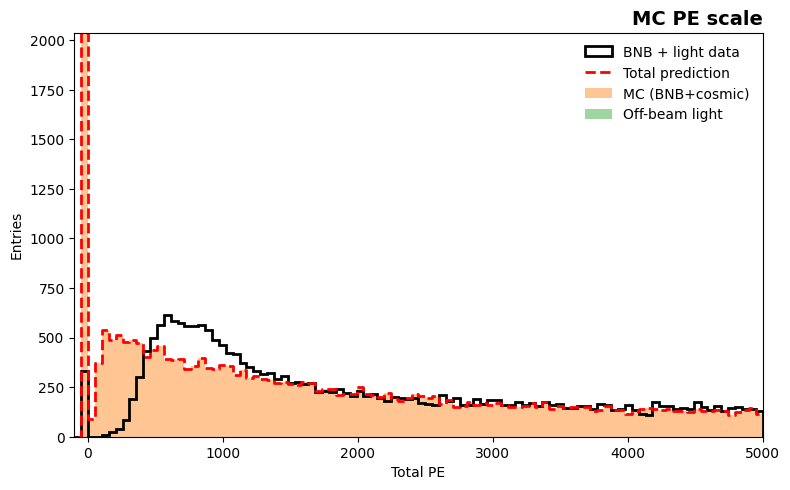

In [25]:
## Check total PE distribution
abs_comp_total_pe_two_mc_stack(mc_bnb_cosmic_hdr_df, data_bnb_light_hdr_df, data_offbeam_light_hdr_df, ('totalpe_timecut'), ('totalpe_timecut'), "Total PE", -10., 40000, 100, "Entries", False, False, "MC PE scale", mc_pot_scale, intime_gate_scale)
abs_comp_total_pe_two_mc_stack(mc_bnb_cosmic_hdr_df, data_bnb_light_hdr_df, data_offbeam_light_hdr_df, ('totalpe_timecut'), ('totalpe_timecut'), "Total PE", -100, 5000, 100, "Entries", False, False, "MC PE scale", mc_pot_scale, intime_gate_scale)

In [26]:
##leave it there, no PE cut for now

## DEFINE PE CUT
total_pe_cut = 2000.
mc_bnb_cosmic_pe_mask = mc_bnb_cosmic_hdr_df["totalpe_timecut"] > total_pe_cut
data_offbeam_pe_mask = data_offbeam_light_hdr_df['totalpe_timecut'] > total_pe_cut
data_bnb_light_pe_mask = data_bnb_light_hdr_df['totalpe_timecut'] > total_pe_cut

In [27]:
## Since evt DataFrame has more level in labels, we should make a mask for considering the difference
def get_evt_pe_mask(mask, df):
    sel_idx = mask[mask].index
    pairs = df.index.droplevel([-2, -1])
    mask2 = pairs.isin(sel_idx)
    return mask2

In [28]:
mc_bnb_cosmic_evt_pe_mask = get_evt_pe_mask(mc_bnb_cosmic_pe_mask, mc_bnb_cosmic_dfs["evt"])
data_offbeam_evt_pe_mask = get_evt_pe_mask(data_offbeam_pe_mask, data_offbeam_light_dfs["evt"])
data_bnb_light_evt_pe_mask = get_evt_pe_mask(data_bnb_light_pe_mask, data_bnb_light_dfs["evt"])

In [29]:
## Double checking for legnths of evt DataFrame and the mask array
print("mc_bnb_cosmic_dfs['evt'] length: %d" %len(mc_bnb_cosmic_dfs['evt']))
print("mc_bnb_cosmic_evt_pe_mask length: %d" %len(mc_bnb_cosmic_evt_pe_mask))

print("data_offbeam_light_dfs['evt'] length: %d" %len(data_offbeam_light_dfs['evt']))
print("data_offbeam_evt_pe_mask length: %d" %len(data_offbeam_evt_pe_mask))

print("data_bnb_light_dfs['evt'] length: %d" %len(data_bnb_light_dfs['evt']))
print("data_bnb_light_evt_pe_mask length: %d" %len(data_bnb_light_evt_pe_mask))

mc_bnb_cosmic_dfs['evt'] length: 3934878
mc_bnb_cosmic_evt_pe_mask length: 3934878
data_offbeam_light_dfs['evt'] length: 1836403
data_offbeam_evt_pe_mask length: 1836403
data_bnb_light_dfs['evt'] length: 3408174
data_bnb_light_evt_pe_mask length: 3408174


In [30]:
## Add PE cut decision (boolean) column to evt DataFrame
mc_bnb_cosmic_dfs["evt"][('pemask', '', '', '', '', '')] = mc_bnb_cosmic_evt_pe_mask
data_bnb_light_dfs["evt"][('pemask', '', '', '', '', '')] = data_bnb_light_evt_pe_mask
data_offbeam_light_dfs["evt"][('pemask', '', '', '', '', '')] = data_offbeam_evt_pe_mask

## Define FV

In [31]:
def InFV_trk(data): # cm
    xmin = -190.
    ymin = -190.
    zmin = 10.
    xmax = 190.
    ymax =  190.
    zmax =  450.
    return (data.x > xmin) & (data.x < xmax) & (data.y > ymin) & (data.y < ymax) & (data.z > zmin) & (data.z < zmax)

def InFV(data): # cm
    xmin = -190.
    ymin = -190.
    zmin = 10.
    xmax = 190.
    ymax =  190.
    zmax =  450.
    return (np.abs(data.x) > 10) & (np.abs(data.x) < 190) & (data.y > ymin) & (data.y < ymax) & (data.z > zmin) & (data.z < zmax)

def InAV(data): # cm
    xmin = -200.
    ymin = -200.
    zmin = 0.
    xmax = 200.
    ymax =  200.
    zmax =  500.
    return (np.abs(data.x) > 10) & (np.abs(data.x) < 190) & (data.y > ymin) & (data.y < ymax) & (data.z > zmin) & (data.z < zmax)


def InFV_xy(data): # cm
    xmin = 10.
    ymin = -190.
    xmax = 190.
    ymax =  190.
    return (np.abs(data.x) > xmin) & (np.abs(data.x) < xmax) & (data.y > ymin) & (data.y < ymax)

## Vetoing high y and high z region
def InFV_nohiyz(data):
    xmin = 10.
    xmax = 190.
    zmin = 10.
    zmax = 450.
    ymax_highz = 100.
    pass_xz = (np.abs(data.x) > xmin) & (np.abs(data.x) < xmax) & (data.z > zmin) & (data.z < zmax)
    pass_y = ((data.z < 250) & (np.abs(data.y) < 190.)) | ((data.z > 250) & (data.y > -190.) & (data.y < ymax_highz))
    return pass_xz & pass_y

def InFV_nohiyz_trk(data):
    xmax = 190.
    zmin = 10.
    zmax = 450.
    ymax_highz = 100.
    pass_xz = (np.abs(data.x) < xmax) & (data.z > zmin) & (data.z < zmax)
    pass_y = ((data.z < 250) & (np.abs(data.y) < 190.)) | ((data.z > 250) & (data.y > -190.) & (data.y < ymax_highz))
    return pass_xz & pass_y

## Match truth and MC and create categories

In [32]:
def get_true_t(df):
    t = (df.E - df.mu.genE - df.cpi.genE)**2 - (df.momentum.x - df.mu.genp.x - df.cpi.genp.x)**2 - (df.momentum.y - df.mu.genp.y - df.cpi.genp.y)**2 - (df.momentum.z - df.mu.genp.z - df.cpi.genp.z)**2
    return np.abs(t)

In [33]:
true_t = get_true_t(mc_bnb_cosmic_dfs['mcnu']).fillna(999999)
mc_bnb_cosmic_dfs['mcnu']['true_t'] = true_t

In [34]:
## For MC BNB + cosmic sample
is_fv = InFV(mc_bnb_cosmic_dfs['mcnu'].position)     #based on the true position
is_cc = mc_bnb_cosmic_dfs['mcnu'].iscc               #based on truth CC info
genie_mode = mc_bnb_cosmic_dfs['mcnu'].genie_mode    #based on true interaction category
w = mc_bnb_cosmic_dfs['mcnu'].w
true_pdg = mc_bnb_cosmic_dfs['mcnu'].pdg
muon_energy = mc_bnb_cosmic_dfs["mcnu"].mu.genE

try :
    nuint_categ = pd.Series(8, index=mc_bnb_cosmic_dfs['mcnu'].index)
except Exception as e:
    print(f"Error init nuint_categ")

nuint_categ[~is_fv] = -1  # Out of FV
nuint_categ[is_fv & is_cc & ((true_pdg == 14) & (muon_energy > 0.1))] = 1 # Signal
nuint_categ[is_fv & ~is_cc] = 0  # NC
nuint_categ[is_fv & is_cc & (~((true_pdg == 14) & (muon_energy > 0.1))) & (genie_mode == 3)] = 2  #  CCCOH
nuint_categ[is_fv & is_cc & (~((true_pdg == 14) & (muon_energy > 0.1))) & (genie_mode == 0)] = 3  # CCQE
nuint_categ[is_fv & is_cc & (~((true_pdg == 14) & (muon_energy > 0.1))) & (genie_mode == 10)] = 4  # 2p2h
nuint_categ[is_fv & is_cc & (~((true_pdg == 14) & (muon_energy > 0.1))) & (genie_mode != 0) & (genie_mode != 3) & (genie_mode != 10) & ((w < 1.4) | (genie_mode == 1))] = 5  # RES
nuint_categ[is_fv & is_cc & (~((true_pdg == 14) & (muon_energy > 0.1))) & (genie_mode != 0) & (genie_mode != 3) & (genie_mode != 10) & ((w > 2.0) | (genie_mode == 2))] = 6  # DIS

mc_bnb_cosmic_dfs['mcnu']['nuint_categ'] = nuint_categ

In [35]:
#### 1) Merging is based on matching between slc.tmatch.idx of evtdf and rec.mc.nu..index of mcnudf.
####    For each entry (readout window), there could be multiple truth neutrino interactions and reconstructed slices
####    We want to match each truth neutrino interaction to a corresponding slice

#It matches the levels of the two datasets to be merged, and then merges them (so all columns and rows join the dataset)


# match for mc bnb cosmic
mc_bnb_cosmic_dfs["mcnu"].columns = pd.MultiIndex.from_tuples([('gen',) + col if isinstance(col, tuple) else ('gen', col) for col in mc_bnb_cosmic_dfs["mcnu"].columns])
mc_bnb_cosmic_dfs["mcnu"].columns = pd.MultiIndex.from_tuples([
    col + ('',) * (6 - len(col)) for col in mc_bnb_cosmic_dfs["mcnu"].columns
])
mc_bnb_cosmic_dfs["evt"] = ph.multicol_merge(mc_bnb_cosmic_dfs["evt"].reset_index(), mc_bnb_cosmic_dfs["mcnu"].reset_index(),
                                            left_on=[('__ntuple', '', '', '', '', ''), ('entry', '', '', '', '', ''), ('slc','tmatch', 'idx', '', '', '')],
                                            right_on=[('__ntuple', '', '', '', '', ''), ('entry', '', '', '', '', ''), ('rec.mc.nu..index', '','', '', '', '')], 
                                            how="left") ## -- save all sllices
mc_bnb_cosmic_dfs["evt"] = mc_bnb_cosmic_dfs["evt"].set_index(["__ntuple", "entry", "rec.slc..index", "rec.slc.reco.pfp..index"], verify_integrity=True)
mc_bnb_cosmic_dfs["evt"].loc[mc_bnb_cosmic_dfs["evt"][('gen', 'nuint_categ', '', '', '', '')].isna(), [('gen', 'nuint_categ', '', '', '', '')]] = -2

data_offbeam_light_dfs["evt"][('gen', 'nuint_categ', '', '', '', '')] = -3

In [36]:
## Check 
mc_bnb_cosmic_dfs["mcnu"].gen.nuint_categ.value_counts()

nuint_categ
-1    119644
 1     21253
 0      8607
 3       133
 5       116
 4        45
 6        41
 2         5
Name: count, dtype: int64

values =  [      0.  505395. 3429483.       0.]
sum values =  3934878.0


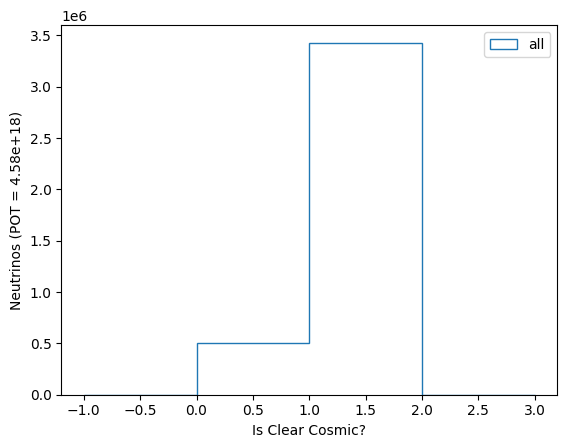

In [37]:
#Plot a variable

var = mc_bnb_cosmic_dfs["evt"].slc.is_clear_cosmic 
values, bins, patches = plt.hist(var, bins=np.linspace(-1., 3., 5), weights=[np.ones_like(data) * 1. for data in var], histtype="step", label=["all"])
print("values = ", values)
print("sum values = ", sum(values))
plt.xlabel("Is Clear Cosmic?")
plt.ylabel(f"Neutrinos (POT = {mc_tot_pot:.2e})")
plt.legend()
plt.show()

sum_value_nocut = sum(values)

In [38]:
mc_bnb_cosmic_dfs["evt"].columns.values

array([('slc', 'barycenterFM', 'chargeTotal', '', '', ''),
       ('slc', 'barycenterFM', 'flashTime', '', '', ''),
       ('slc', 'barycenterFM', 'flashPEs', '', '', ''),
       ('slc', 'barycenterFM', 'chi2', '', '', ''),
       ('slc', 'barycenterFM', 'score', '', '', ''),
       ('slc', 'barycenterFM', 'deltaZ', '', '', ''),
       ('slc', 'is_clear_cosmic', '', '', '', ''),
       ('slc', 'vertex', 'x', '', '', ''),
       ('slc', 'vertex', 'y', '', '', ''),
       ('slc', 'vertex', 'z', '', '', ''),
       ('slc', 'self', '', '', '', ''),
       ('slc', 'tmatch', 'eff', '', '', ''),
       ('slc', 'tmatch', 'pur', '', '', ''),
       ('slc', 'tmatch', 'idx', '', '', ''),
       ('slc', 'producer', '', '', '', ''),
       ('slc', 'nuid', 'crlongtrkdiry', '', '', ''),
       ('slc', 'nu_score', '', '', '', ''),
       ('slc', 'opt0', 'score', '', '', ''),
       ('slc', 'opt0', 'time', '', '', ''),
       ('slc', 'opt0', 'measPE', '', '', ''),
       ('slc', 'opt0', 'hypoPE', '', '

## Set up plotting

In [39]:

mode_list = [1, 2, 0, 3, 4, 5, 6, -1, -2, -3]
mode_labels = ["Signal", "CC COH (non. Sig)", "NC (non. Sig)", "QE (non. Sig)", "2p2h (non. Sig)", "RES (non. Sig)", "DIS (non. Sig)", "Non-FV (non. Sig)", "Others (non. Sig)", "Intime Cosmics (non. Sig)"]
colors = ['#d62728',  # Red            Signal
          '#1f77b4',  # Blue           NS CCCOH
          '#ff7f0e',  # Orange          NC
          '#2ca02c',  # Green           QE
          '#17becf',  # Teal           2p2h
          '#9467bd',  # Purple         RES
          '#8c564b',  # Brown           DIS
          '#e377c2',  # Pink            NON FV
          '#7f7f7f',  # Gray             Other
          '#bcbd22']  # Yellow-green      In time cosmics

def draw_reco_stacked_hist(var_mc, var_offbeam_data, is_logx, is_logy,
                           title_x, title_y, x_min, x_max, nbins, outname,
                           data_overlay=False, var_data=[], draw_density=False):
    
    ## Define the output figure to have two pads
    fig = plt.figure(figsize=(8, 8), dpi=100)
    gs = gridspec.GridSpec(2, 1, height_ratios=[5, 1], hspace=0.10)
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    if is_logx:
        ax_main.set_xscale('log')
        ax_ratio.set_xscale('log')        
    if is_logy:
        ax_main.set_yscale('log')


    ax_main.set_xlabel("")  # Only bottom has x-label
    ax_main.set_ylabel(title_y)
    ax_ratio.set_ylabel("Data/MC", fontsize=12)
    ax_ratio.set_xlabel(title_x, fontsize = 20)

    ax_ratio.axhline(1.0, color='red', linestyle='--', linewidth=1)
    ax_ratio.set_ylabel("Data/MC", fontsize=12)
    ax_ratio.set_xlabel(title_x, fontsize=12)
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.tick_params(width=2, length=6)
    for spine in ax_ratio.spines.values():
        spine.set_linewidth(2)

    plt.setp(ax_main.get_xticklabels(), visible=False)

    ## Defind binning
    if is_logx:
        bins = np.logspace(np.log10(x_min), np.log10(x_max), nbins + 1)
        bin_centers = np.sqrt(bins[:-1] * bins[1:])
    else:
        bins = np.linspace(x_min, x_max, nbins + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])

    ## Define data for MC
    all_mc_data = var_mc + var_offbeam_data
    #print("len all_mc_data ", len(all_mc_data[0]))
    all_weights = (
        [np.ones_like(data) * mc_pot_scale for data in var_mc] + 
        [np.ones_like(data) * intime_gate_scale for data in var_offbeam_data]
    )
    #print("all_weights ", all_weights)
    each_mc_hist_data = [np.histogram(data, bins=bins, weights=w)[0] for data, w in zip(all_mc_data, all_weights)]
    total_mc = np.sum(each_mc_hist_data, axis=0)
    print("total_mc ", total_mc)

    #each_mc_hist_data2 = [np.histogram(data, bins=bins)[0] for data in zip(var_mc)]
    #for item in each_mc_hist_data2:
     #   print(item)
    #print(len(var_mc))
    #total_mc2 = np.sum(each_mc_hist_data2, axis=0)
    #print("total_mc 2 ", total_mc2)

    ## Plot stacked MC
    hist_data, bins, _ = ax_main.hist(all_mc_data,
                                      bins=bins,
                                      weights=all_weights,
                                      stacked=True,
                                      color=colors,
                                      label=mode_labels,
                                      edgecolor='none',
                                      linewidth=0,
                                      density=draw_density,
                                      histtype='stepfilled')

    max_y = np.max(total_mc)

    ## Plot MC stat error box
    each_mc_hist_data = []
    each_mc_hist_err2 = []  # sum of squared weights for error

    for data, w in zip(all_mc_data, all_weights):
        hist_vals, _ = np.histogram(data, bins=bins, weights=w)
        hist_err2, _ = np.histogram(data, bins=bins, weights=np.square(w))
        each_mc_hist_data.append(hist_vals)
        each_mc_hist_err2.append(hist_err2)

    total_mc = np.sum(each_mc_hist_data, axis=0)
    total_mc_err2 = np.sum(each_mc_hist_err2, axis=0)
    mc_stat_err = np.sqrt(total_mc_err2)
    #mc_stat_err = np.sqrt(total_mc)

    ax_main.bar(
       bin_centers,
        2 * mc_stat_err,
        width=np.diff(bins),
        bottom=total_mc - mc_stat_err,
        facecolor='none',             # transparent fill
        edgecolor='black',            # outline color of the hatching
        hatch='xxxx',                 # hatch pattern similar to ROOT's 3004
        linewidth=0.0,
        label='MC Stat. Unc.'
    )

    ax_main.tick_params(width=2, length=10)
    for spine in ax_main.spines.values():
        spine.set_linewidth(2)

    ## Draw Ratio error bar
    mc_stat_err_ratio = mc_stat_err / total_mc
    mc_content_ratio = total_mc / total_mc
    mc_stat_err_ratio = np.nan_to_num(mc_stat_err_ratio, nan=0.)
    mc_content_ratio = np.nan_to_num(mc_content_ratio, nan=-999.)
    ax_ratio.bar(
        bin_centers,
        2*mc_stat_err_ratio,
        width=np.diff(bins),
        bottom=mc_content_ratio - mc_stat_err_ratio,
        facecolor='none',             # transparent fill
        edgecolor='black',            # outline color of the hatching
        hatch='xxxx',                 # hatch pattern similar to ROOT's 3004
        linewidth=0.0,
        label='MC Stat. Unc.'
    )

    ## Draw data too
    if data_overlay:
        ax_main.set_ylabel("Events (POT = %.2e)" % target_pot)
        if draw_density:
            ax_main.set_ylabel("A.U.")

        ## Define data histogram
        counts, _ = np.histogram(var_data, bins=bins)

        bin_widths = np.diff(bins)
        total_data = np.sum(counts)
        print("total data = ", total_data)
        norm_counts = counts
        data_eylow, data_eyhigh = sh.return_data_stat_err(counts)

        if draw_density:
            norm_counts = counts / (total_data * bin_widths)
            data_eylow = data_eylow / (total_data * bin_widths) if total_data > 0 else np.zeros_like(counts)
            data_eyhigh = data_eyhigh / (total_data * bin_widths) if total_data > 0 else np.zeros_like(counts)

        errors = data_eylow + data_eyhigh
        
        ## Plot data points on main histogram
        #ax_main.errorbar(bin_centers, norm_counts, yerr=errors,
        #                 fmt='o', color='black', label='Data',
        #                 markersize=5, capsize=3, linewidth=1.5)
        
        ax_main.errorbar(bin_centers, norm_counts,
                 yerr=np.vstack((data_eylow, data_eyhigh)),
                 fmt='o', color='black', label='Data',
                 markersize=5, capsize=3, linewidth=1.5)
        
        max_y_data = np.max(norm_counts + data_eyhigh)
        #print("max_y: %f" %(max_y))
        #print("max_y_data: %f" %(max_y_data))
        max_y = max(max_y, max_y_data)
        #print("max_y: %f" %(max_y))

        ## Make data/mc ratio plot
        data_ratio = norm_counts / total_mc
        print(norm_counts)
        print(total_mc)
        print("data ratio ", data_ratio)
        data_ratio_eylow = data_eylow / total_mc
        data_ratio_eyhigh = data_eyhigh / total_mc
        data_ratio = np.nan_to_num(data_ratio, nan=-999.)
        data_ratio_eylow = np.nan_to_num(data_ratio_eylow, nan=0.)
        data_ratio_eyhigh = np.nan_to_num(data_ratio_eyhigh, nan=0.)
        
        #data_ratio_errors = data_ratio_eylow + data_ratio_eyhigh
        #ax_ratio.errorbar(bin_centers, data_ratio, yerr=data_ratio_errors,
        #                 fmt='o', color='black', label='Data',
        #                 markersize=5, capsize=3, linewidth=1.5)

        ax_ratio.errorbar(bin_centers, data_ratio,
                  yerr=np.vstack((data_ratio_eylow, data_ratio_eyhigh)),
                  fmt='o', color='black', label='Data',
                  markersize=5, capsize=3, linewidth=1.5)

    ## Set ax_main axes variables
    ax_main.set_xlim(x_min, x_max)
    ax_main.set_ylim(0.0, max_y * 1.5)
    if is_logy:
        ax_main.set_ylim(0.1, max_y * 600)
    
    # Legend with fractions
    accum_sum = [np.sum(data) for data in hist_data]
    accum_sum = [0.] + accum_sum
    total_sum = accum_sum[-1]
    individual_sums = [accum_sum[i + 1] - accum_sum[i] for i in range(len(accum_sum) - 1)]
    print("mode sums = ", individual_sums)
    print("total sums = ", total_sum)
    fractions = [(count / total_sum) * 100 for count in individual_sums]
    legend_labels = [f"{label} ({frac:.1f}%)" for label, frac in zip(mode_labels[::-1], fractions[::-1])]
    if data_overlay:
        if draw_density:
            legend_labels.append("Data")
        else:
            legend_labels.append(f"Total MC Stat. Unc. ({total_sum:.0f})")
            legend_labels.append(f"Data ({total_data:.0f})")
            #legend_labels.append(f"Data ({total_data:.0f})")
    ax_main.legend(legend_labels, loc='upper left', fontsize=8, frameon=False, ncol=3, bbox_to_anchor=(0.05, 0.98))

    legend_labels_ratio = ["y=1", "MC (Stat. Only)", "Data/MC"]
    ax_ratio.legend(legend_labels_ratio, loc='upper left', fontsize=6, frameon=False, ncol=3, bbox_to_anchor=(0.05, 0.98))


    ax_main.text(0.00, 1.02, "SBND " + sample_str + ", Preliminary",
                 transform=ax_main.transAxes, fontsize=14, fontweight='bold')

    #fig.savefig("./plots/pandora_df/2025_v10_06_00_05/data_vs_mc_tpc/" + outname + ".pdf", format='pdf', bbox_inches='tight')
    plt.show()
    plt.close()

In [40]:
#this looks like it's seeing which selected reco events are also true signal events?

def draw_mc_data_shape_comp_per_slc(mc_bnb_cosmic_df, data_offbeam_df, data_df, column, x_title, y_title, x_min, x_max, n_bins, out_name, is_logx = False, is_logy = False):
    nuint_categ_col = ('gen', 'nuint_categ', '', '', '', '')

    mc_bnb_cosmic_df_per_slc = mc_bnb_cosmic_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column, nuint_categ_col]].first()
    data_offbeam_df_per_slc = data_offbeam_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column, nuint_categ_col]].first()

    data_df_per_slc = data_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column]].first()

    mode_list_mc = [m for m in mode_list if ((m != -3) and (m != -4))]
    var_mc_bnb_cosmic = [mc_bnb_cosmic_df_per_slc[mc_bnb_cosmic_df_per_slc[nuint_categ_col] == mode][column]for mode in mode_list_mc]
    var_data_offbeam = [data_offbeam_df_per_slc[data_offbeam_df_per_slc.gen.nuint_categ == -3][column]]
    var_data = data_df_per_slc[column]
    draw_reco_stacked_hist(var_mc_bnb_cosmic, var_data_offbeam, is_logx, is_logy, x_title, y_title, x_min, x_max, n_bins, out_name, True, var_data)


In [41]:
### For drawing data blind plots: this function does not draw data points in bins with singal contribution greater than 10%
def draw_reco_stacked_hist_blind(
    var_mc, var_offbeam_data, is_logx, is_logy,
    title_x, title_y, x_min, x_max, nbins, outname,
    data_overlay=False, var_data=[], draw_density=False,
    blind=True, blind_req=0.1
):
    fig = plt.figure(figsize=(8, 8), dpi=100)
    gs = gridspec.GridSpec(2, 1, height_ratios=[5, 1], hspace=0.10)
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)

    if is_logx:
        ax_main.set_xscale('log')
        ax_ratio.set_xscale('log')
    if is_logy:
        ax_main.set_yscale('log')

    ax_main.set_xlabel("")
    ax_main.set_ylabel(title_y)
    ax_ratio.set_ylabel("Data/MC", fontsize=12)
    ax_ratio.set_xlabel(title_x, fontsize=12)
    ax_ratio.axhline(1.0, color='red', linestyle='--', linewidth=1)
    ax_ratio.set_ylim(0.4, 1.6)
    ax_ratio.tick_params(width=2, length=6)
    for spine in ax_ratio.spines.values():
        spine.set_linewidth(2)

    plt.setp(ax_main.get_xticklabels(), visible=False)

    bins = np.logspace(np.log10(x_min), np.log10(x_max), nbins + 1) if is_logx else np.linspace(x_min, x_max, nbins + 1)
    bin_centers = np.sqrt(bins[:-1] * bins[1:]) if is_logx else 0.5 * (bins[:-1] + bins[1:])

    all_mc_data = var_mc + var_offbeam_data
    all_weights = (
        [np.ones_like(data) * mc_pot_scale for data in var_mc] +
        [np.ones_like(data) * intime_gate_scale for data in var_offbeam_data]
    )

    each_mc_hist_data = [
        np.histogram(data, bins=bins, weights=w)[0]
        for data, w in zip(all_mc_data, all_weights)
    ]
    total_mc = np.sum(each_mc_hist_data, axis=0)

    hist_data, bins, _ = ax_main.hist(
        all_mc_data, bins=bins, weights=all_weights,
        stacked=True, color=colors, label=mode_labels,
        edgecolor='none', linewidth=0, density=draw_density, histtype='stepfilled'
    )

    max_y = np.max(total_mc)
    each_mc_hist_data = []
    each_mc_hist_err2 = []  # sum of squared weights for error

    for data, w in zip(all_mc_data, all_weights):
        hist_vals, _ = np.histogram(data, bins=bins, weights=w)
        hist_err2, _ = np.histogram(data, bins=bins, weights=np.square(w))
        each_mc_hist_data.append(hist_vals)
        each_mc_hist_err2.append(hist_err2)

    total_mc = np.sum(each_mc_hist_data, axis=0)
    total_mc_err2 = np.sum(each_mc_hist_err2, axis=0)
    mc_stat_err = np.sqrt(total_mc_err2)
    #mc_stat_err = np.sqrt(total_mc)

    ax_main.bar(
        bin_centers, 2 * mc_stat_err,
        width=np.diff(bins), bottom=total_mc - mc_stat_err,
        facecolor='none', edgecolor='black', hatch='xxxx',
        linewidth=0.0, label='MC Stat. Unc.'
    )

    mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
    mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
    ax_ratio.bar(
        bin_centers, 2 * mc_stat_err_ratio,
        width=np.diff(bins), bottom=mc_content_ratio - mc_stat_err_ratio,
        facecolor='none', edgecolor='black', hatch='xxxx',
        linewidth=0.0, label='MC Stat. Unc.'
    )

    if data_overlay:
        ax_main.set_ylabel("A.U." if draw_density else f"Events (POT = {target_pot:.2e})")

        counts, _ = np.histogram(var_data, bins=bins)
        bin_widths = np.diff(bins)
        total_data = np.sum(counts)

        norm_counts = counts
        data_eylow, data_eyhigh = sh.return_data_stat_err(counts)
        if draw_density and total_data > 0:
            norm_counts = counts / (total_data * bin_widths)
            data_eylow = data_eylow / (total_data * bin_widths)
            data_eyhigh = data_eyhigh / (total_data * bin_widths)
        elif draw_density:
            norm_counts[:] = 0
            data_eylow[:] = 0
            data_eyhigh[:] = 0

        ### --> Apply blinding to bins where Signal fraction > blind_req
        if blind:
            signal_mc = each_mc_hist_data[0]  # index 0 = "Signal"
            signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
            blind_bins = signal_frac > blind_req
            norm_counts[blind_bins] = -1
            data_eylow[blind_bins] = 0
            data_eyhigh[blind_bins] = 0

        ax_main.errorbar(
            bin_centers, norm_counts,
            yerr=np.vstack((data_eylow, data_eyhigh)),
            fmt='o', color='black', label='Data',
            markersize=5, capsize=3, linewidth=1.5
        )

        max_y_data = np.max(norm_counts + data_eyhigh)
        max_y = max(max_y, max_y_data)

        data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
        data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
        data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)

        ax_ratio.errorbar(
            bin_centers, data_ratio,
            yerr=np.vstack((data_ratio_eylow, data_ratio_eyhigh)),
            fmt='o', color='black', label='Data',
            markersize=5, capsize=3, linewidth=1.5
        )

    ax_main.set_xlim(x_min, x_max)
    ax_main.set_ylim(0.1 if is_logy else 0.0, max_y * (600 if is_logy else 1.5))

    accum_sum = [np.sum(data) for data in hist_data]
    accum_sum = [0.] + accum_sum
    total_sum = accum_sum[-1]
    individual_sums = [accum_sum[i+1] - accum_sum[i] for i in range(len(accum_sum)-1)]
    fractions = [(count / total_sum) * 100 for count in individual_sums]
    legend_labels = [f"{label} ({frac:.1f}%)" for label, frac in zip(mode_labels[::-1], fractions[::-1])]

    if data_overlay:
        if draw_density:
            legend_labels.append("Data")
        else:
            legend_labels.append(f"Total MC Stat. Unc. ({total_sum:.0f})")
            legend_labels.append(f"Data ({total_data:.0f})")

    ax_main.legend(legend_labels, loc='upper left', fontsize=10, frameon=False, ncol=3, bbox_to_anchor=(0.05, 0.98))
    ax_ratio.legend(["y=1", "MC (Stat. Only)", "Data/MC"], loc='upper left', fontsize=7, frameon=False, ncol=3, bbox_to_anchor=(0.05, 0.98))

    ax_main.text(0.00, 1.02, "SBND " + sample_str + ", Preliminary",
                 transform=ax_main.transAxes, fontsize=14, fontweight='bold')

    #fig.savefig(f"./plots/pandora_df/2025_v10_06_00_05/data_vs_mc_tpc/{outname}.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    plt.close()

def draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df,  data_offbeam_df, data_df, column, x_title, y_title, x_min, x_max, n_bins, out_name, is_logx = False, is_logy = False, blind = True, blind_req = 0.1):
    nuint_categ_col = ('gen', 'nuint_categ', '', '', '', '')

    mc_bnb_cosmic_df_per_slc = mc_bnb_cosmic_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column, nuint_categ_col]].first()
    data_offbeam_df_per_slc = data_offbeam_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column, nuint_categ_col]].first()
    data_df_per_slc = data_df.groupby([('__ntuple'), ('entry'), ('rec.slc..index')])[[column]].first()

    mode_list_mc = [m for m in mode_list if ((m != -3) and (m != -4))]
    var_mc_bnb_cosmic = [mc_bnb_cosmic_df_per_slc[mc_bnb_cosmic_df_per_slc[nuint_categ_col] == mode][column]for mode in mode_list_mc]
    var_data_offbeam = [data_offbeam_df_per_slc[data_offbeam_df_per_slc.gen.nuint_categ == -3][column]]
    var_data = data_df_per_slc[column]

    draw_reco_stacked_hist_blind(var_mc_bnb_cosmic, var_data_offbeam, is_logx, is_logy, x_title, y_title, x_min, x_max, n_bins, out_name, True, var_data, False, blind, blind_req)

In [42]:
#Draw plots for a number of variables

def draw_reco_valid_plots(mc_bnb_cosmic_df, data_offbeam_df, data_df, suffix, is_logx = False, is_logy = False):
    ## draw 1) clear cosmic, 2) nu score, 3) vertex x,y and z
    
    ## -- 2) Clear cosmic
    clear_cosmic_col = ('slc', 'is_clear_cosmic', '', '', '', '')
    draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df, data_offbeam_df, data_df, clear_cosmic_col, "Is Clear Cosmic", "A.U.", -0.5, 1.5, 2, suffix + "_slc_is_clear_cosmic", is_logx, is_logy)

    ## -- 1) flash pe
    opt0_score_col = ('slc', 'opt0', 'score', '', '', '')
    fractions_opt0_score = draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df, data_offbeam_df, data_df, opt0_score_col, "Opt0 Score", "A.U.", -4000, 4000, 100, suffix + "_slc_opt0_score", is_logx, is_logy)

    ## -- 3) vertex x,y,z
    vtx_x_col = ('slc', 'vertex', 'x', '', '', '')
    vtx_y_col = ('slc', 'vertex', 'y', '', '', '')
    vtx_z_col = ('slc', 'vertex', 'z', '', '', '')
    fractions_vtx_x = draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df, data_offbeam_df, data_df, vtx_x_col, "Slice Vertex X [cm]", "A.U.", -300, 300, 100, suffix + "_slc_vtx_x", is_logx, is_logy)
    fractions_vtx_y = draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df, data_offbeam_df, data_df, vtx_y_col, "Slice Vertex Y [cm]", "A.U.", -300, 300, 100, suffix + "_slc_vtx_y", is_logx, is_logy)
    fractions_vtx_z = draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df, data_offbeam_df, data_df, vtx_z_col, "Slice Vertex Z [cm]", "A.U.", -100, 600, 100, suffix + "_slc_vtx_z", is_logx, is_logy)

    ## -- 4) muon candidate
    trk_len_col = ('pfp', 'trk', 'len', '', '', '')
    fractions_trk_len = draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df, data_offbeam_df, data_df, trk_len_col, "Track Length [cm]", "A.U.", 0, 400, 40, suffix + "_pfp_trk_len", is_logx, is_logy)

    trk_score_col = ('pfp', 'trackScore', '', '', '', '')
    fractions_trk_score = draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df, data_offbeam_df, data_df, trk_score_col, "Track Score", "A.U.", 0, 1, 50, suffix + "_pfp_trk_score", is_logx, is_logy)
    
    trk_chi2_muon_col = ('pfp', 'trk', 'chi2pid', 'I2', 'chi2_muon', '')
    trk_chi2_proton_col = ('pfp', 'trk', 'chi2pid', 'I2', 'chi2_proton', '')
    fractions_trk_chi2_mu = draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df, data_offbeam_df, data_df, trk_chi2_muon_col, "Track Chi2 Muon", "A.U.", 0, 100, 100, suffix + "_pfp_trk_chi2_muon", is_logx, is_logy)
    fractions_trk_chi2_pro = draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df, data_offbeam_df, data_df, trk_chi2_proton_col, "Track Chi2 Proton", "A.U.", 0, 100, 100, suffix + "_pfp_trk_chi2_proton", is_logx, is_logy)

    ## -- 5) Barycentre flash score
    bary_score_col = ('slc', 'barycenterFM', 'score', '', '', '')
    fractions_bary_score = draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df, data_offbeam_df, data_df, bary_score_col, "Bary Flash Score", "A.U.", 0, 2, 40, suffix + "_bary_score", is_logx, is_logy)

    ## -- 6) muon candidate end point
    trk_end_z_col = ('pfp', 'trk', 'end', 'z', '', '')
    fractions_trks_end_z = draw_mc_data_shape_comp_per_slc_blind(mc_bnb_cosmic_df, data_offbeam_df, data_df, trk_end_z_col, "PFP End Z [cm]", "A.U.", -100, 600, 100, suffix + "_slc_end_z", is_logx, is_logy)

    
    #return fractions_clear_cosmic, fractions_nu_score, fractions_vtx_x, fractions_vtx_y, fractions_vtx_z, fractions_trk_len 


In [43]:
data_bnb_light_dfs["evt"].columns.values

array([('slc', 'barycenterFM', 'chargeTotal', '', '', ''),
       ('slc', 'barycenterFM', 'flashTime', '', '', ''),
       ('slc', 'barycenterFM', 'flashPEs', '', '', ''),
       ('slc', 'barycenterFM', 'chi2', '', '', ''),
       ('slc', 'barycenterFM', 'score', '', '', ''),
       ('slc', 'barycenterFM', 'deltaZ', '', '', ''),
       ('slc', 'is_clear_cosmic', '', '', '', ''),
       ('slc', 'vertex', 'x', '', '', ''),
       ('slc', 'vertex', 'y', '', '', ''),
       ('slc', 'vertex', 'z', '', '', ''),
       ('slc', 'self', '', '', '', ''),
       ('slc', 'tmatch', 'eff', '', '', ''),
       ('slc', 'tmatch', 'pur', '', '', ''),
       ('slc', 'tmatch', 'idx', '', '', ''),
       ('slc', 'producer', '', '', '', ''),
       ('slc', 'nuid', 'crlongtrkdiry', '', '', ''),
       ('slc', 'nu_score', '', '', '', ''),
       ('slc', 'opt0', 'score', '', '', ''),
       ('slc', 'opt0', 'time', '', '', ''),
       ('slc', 'opt0', 'measPE', '', '', ''),
       ('slc', 'opt0', 'hypoPE', '', '

In [44]:
mc_bnb_cosmic_dfs["mcnu"].gen.nuint_categ.value_counts()

nuint_categ
-1    119644
 1     21253
 0      8607
 3       133
 5       116
 4        45
 6        41
 2         5
Name: count, dtype: int64

In [45]:
mc_bnb_cosmic_dfs["evt"].gen.nuint_categ.value_counts()

nuint_categ
-2.0    3758259
 1.0      85088
-1.0      72817
 0.0      17222
 5.0        573
 3.0        470
 6.0        254
 4.0        176
 2.0         19
Name: count, dtype: int64

In [46]:
data_offbeam_light_dfs["evt"].gen.nuint_categ.value_counts()

nuint_categ
-3    1836403
Name: count, dtype: int64

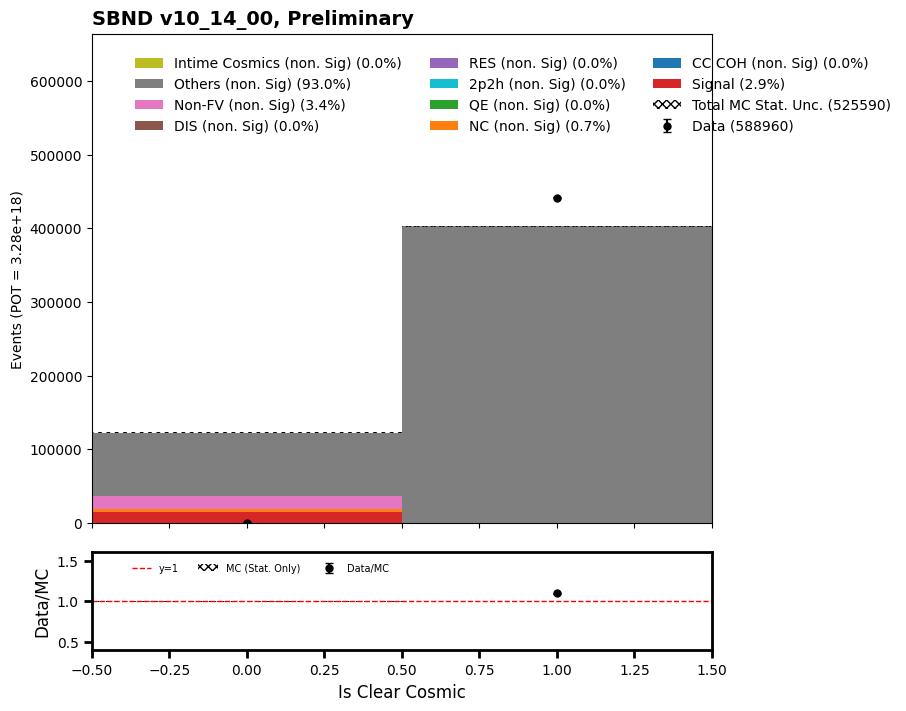

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


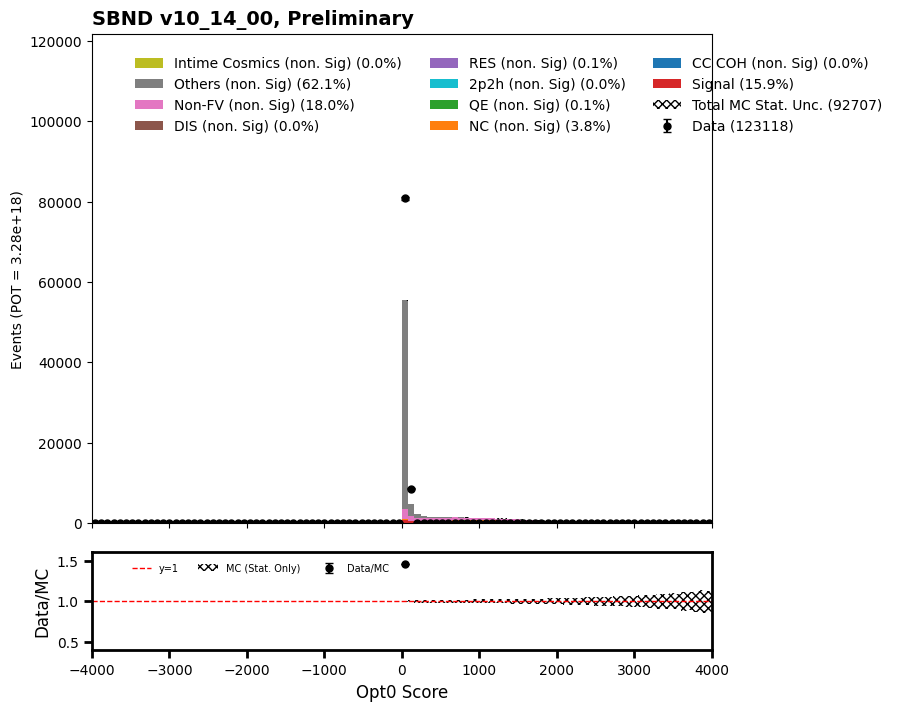

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


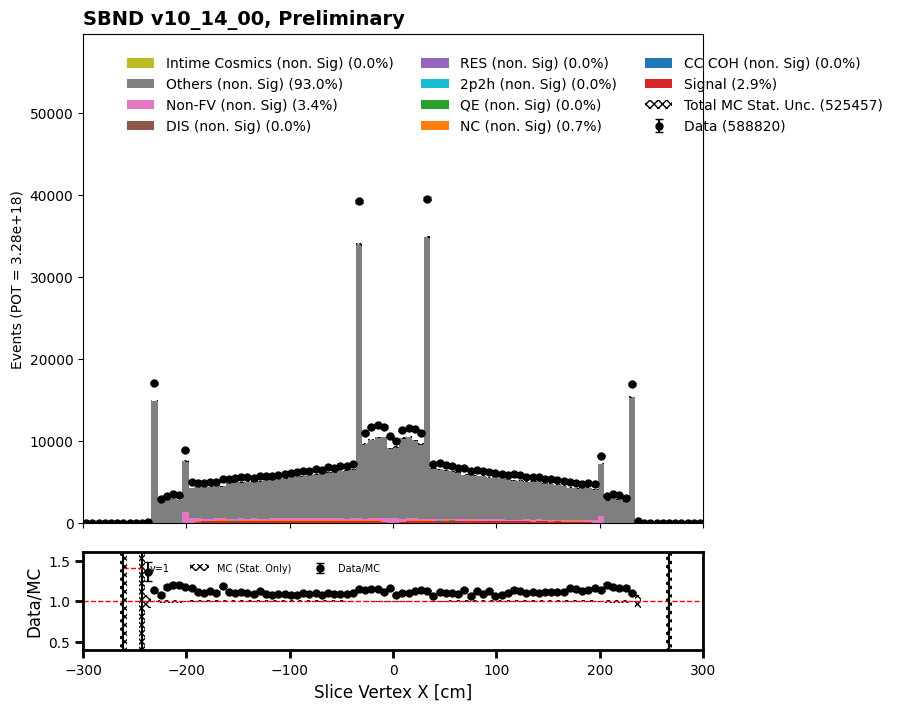

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

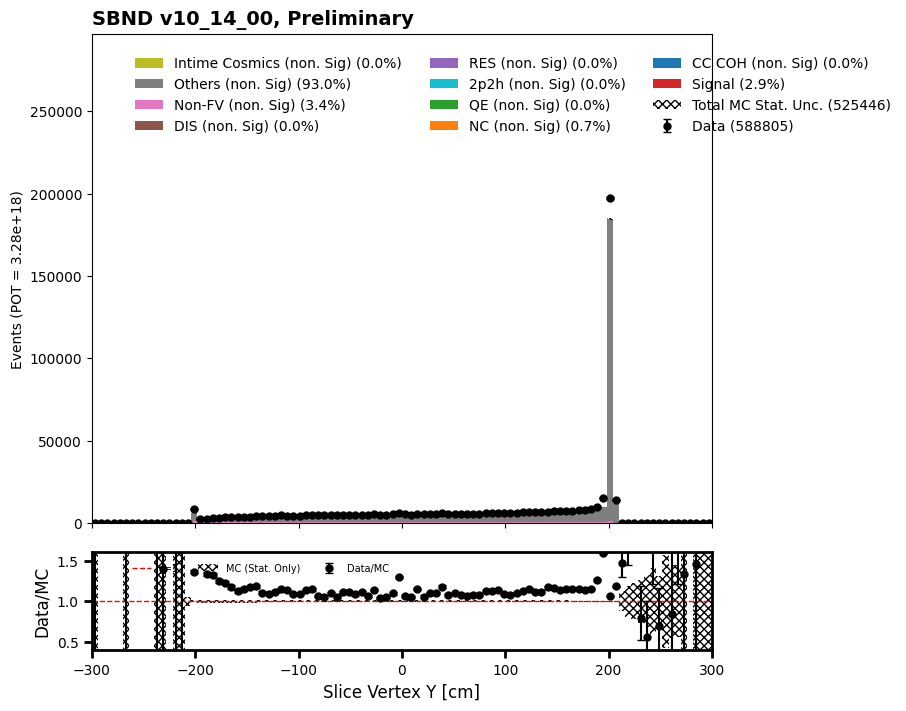

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

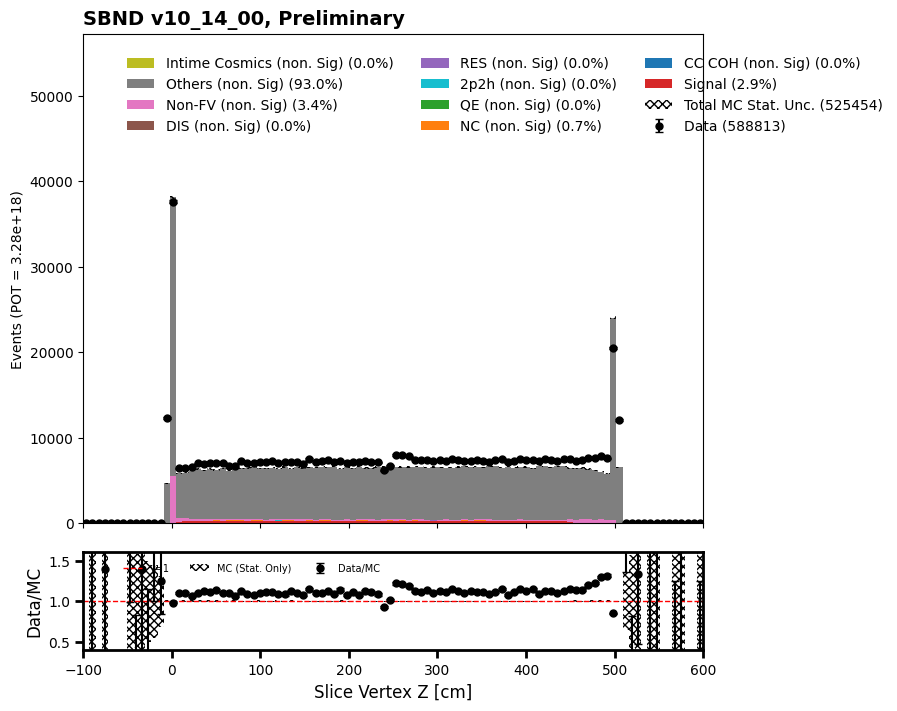

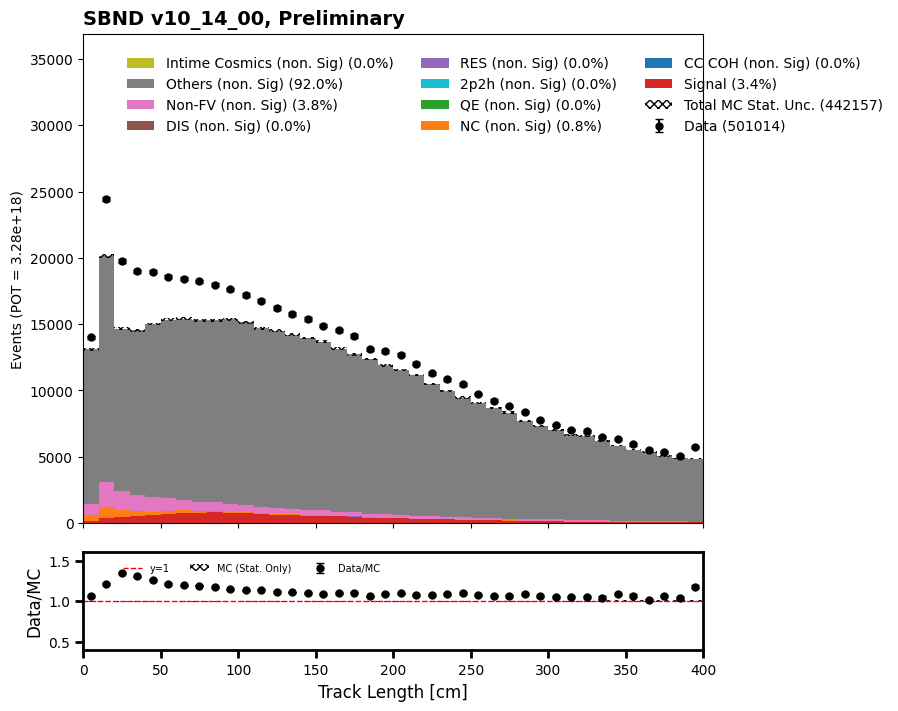

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


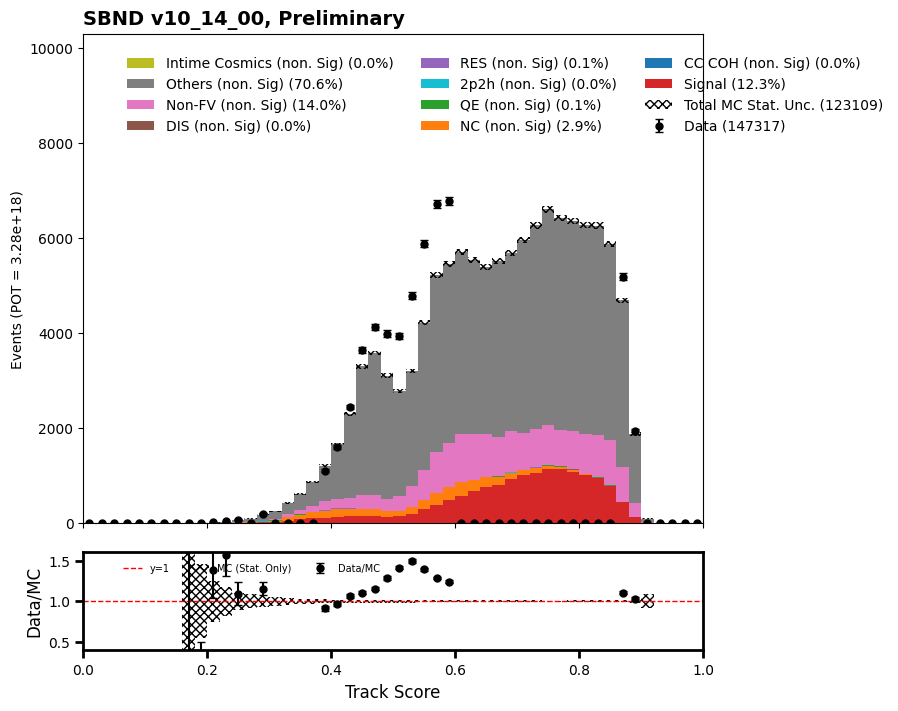

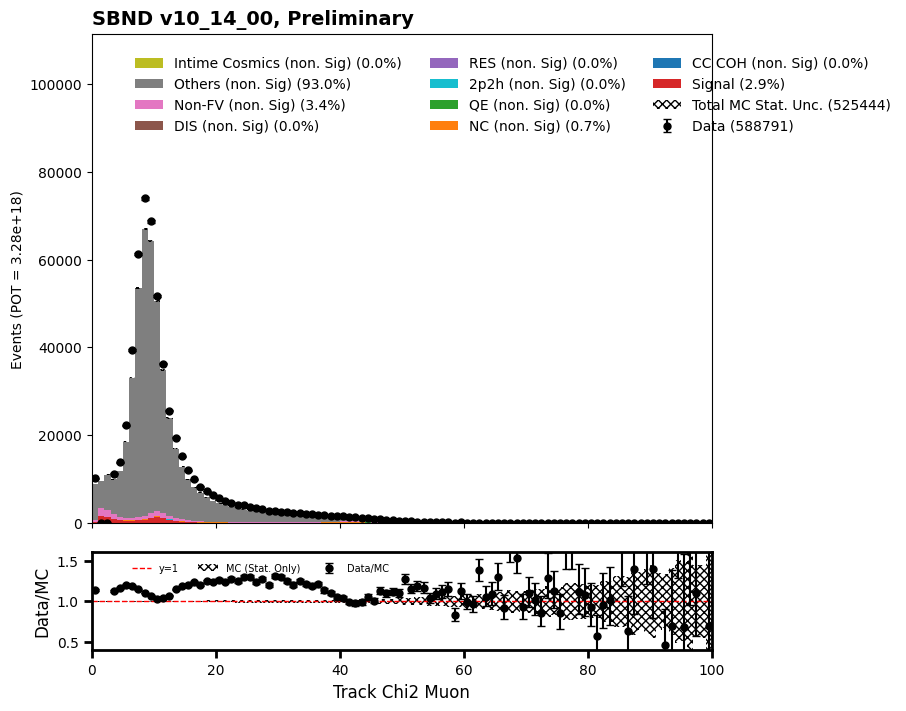

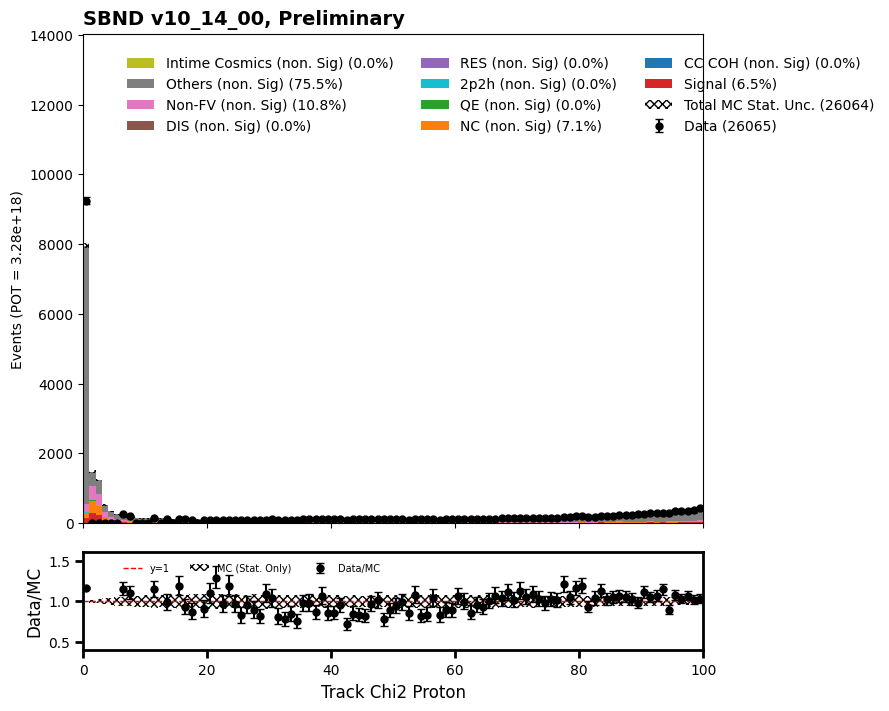

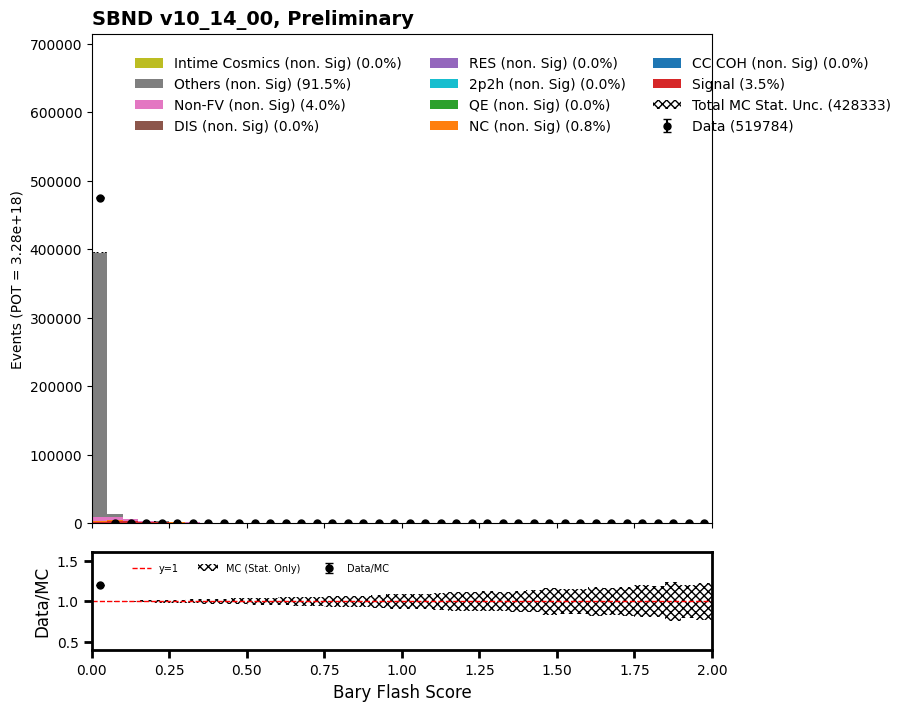

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

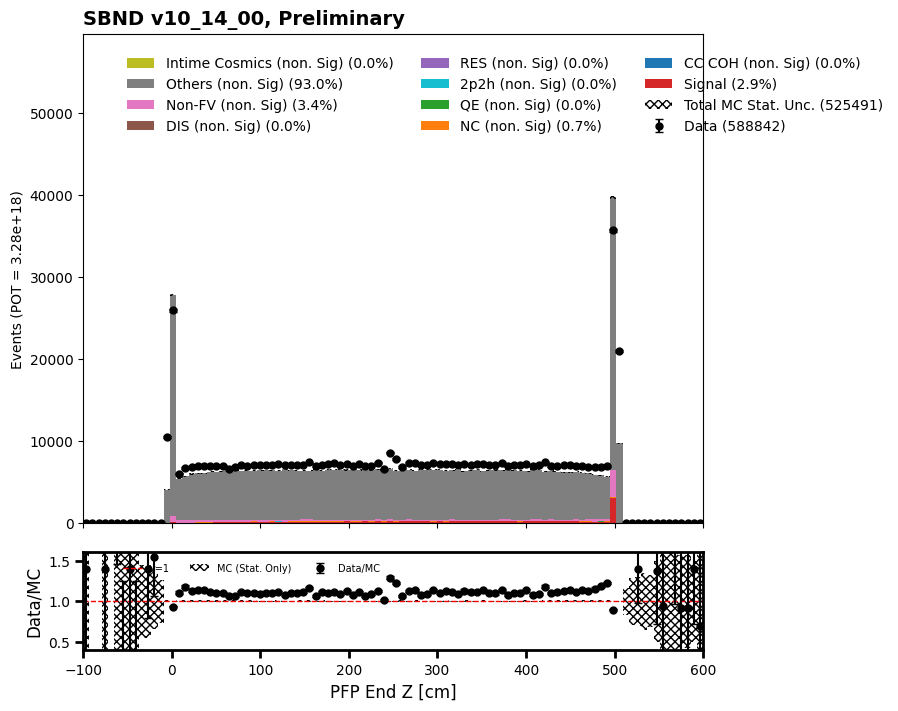

In [47]:
## Reco 1) Nocut
draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"], data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "no_cut")

In [48]:
purity = 15446.2763671875/525590.2702870369
efficiency = 15446.2763671875/15446.2763671875
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  2.94 % and efficiency =  100.0 %


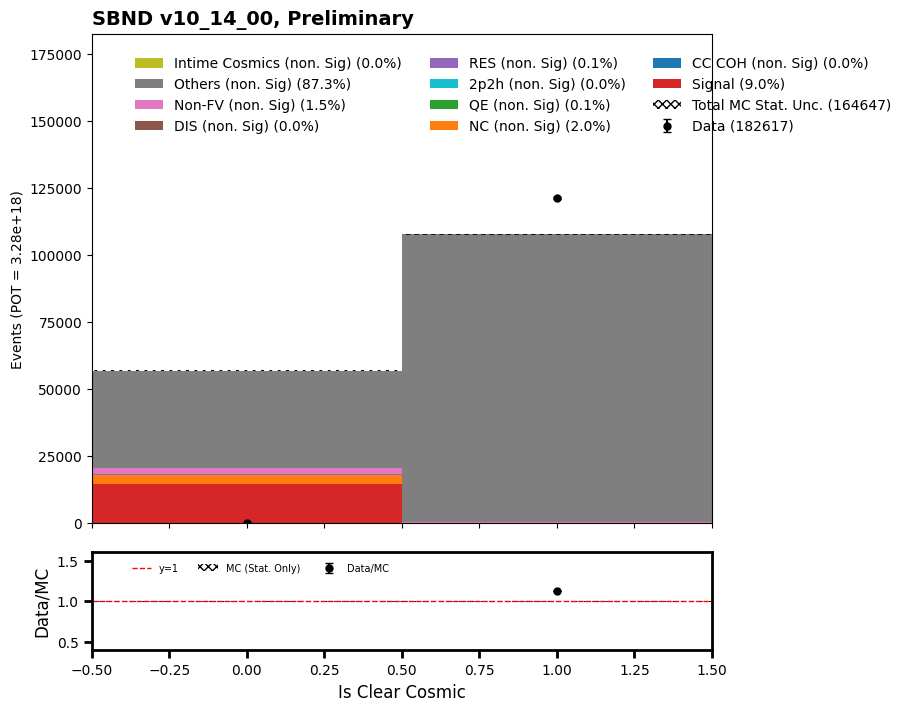

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


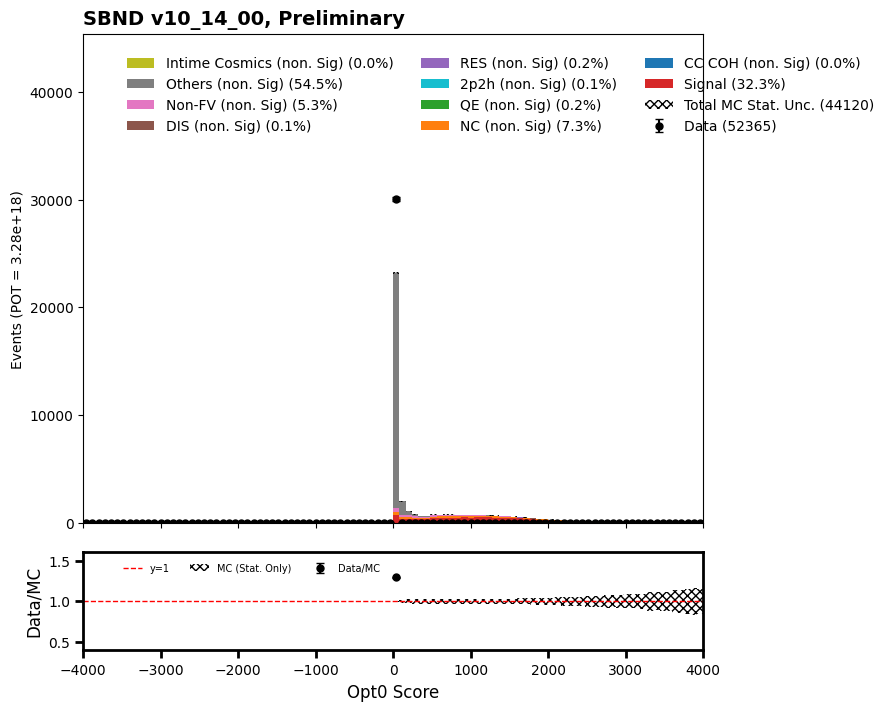

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


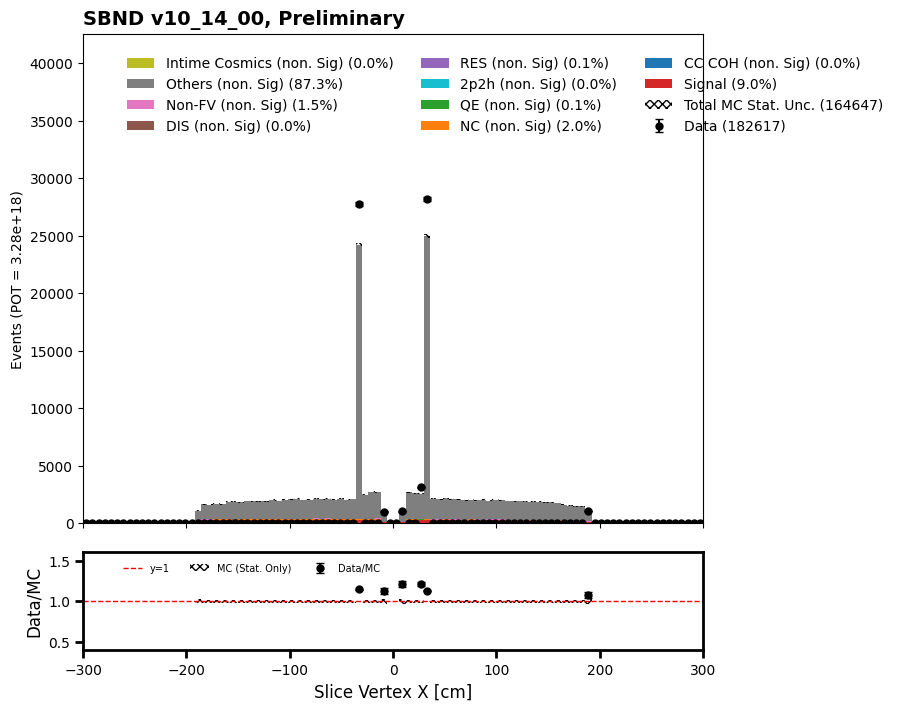

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


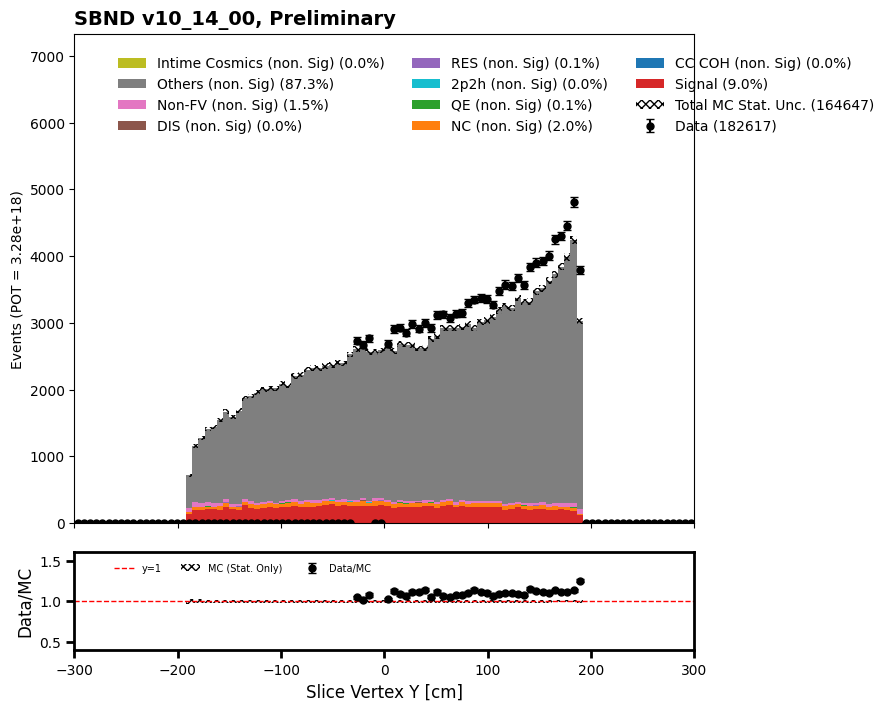

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


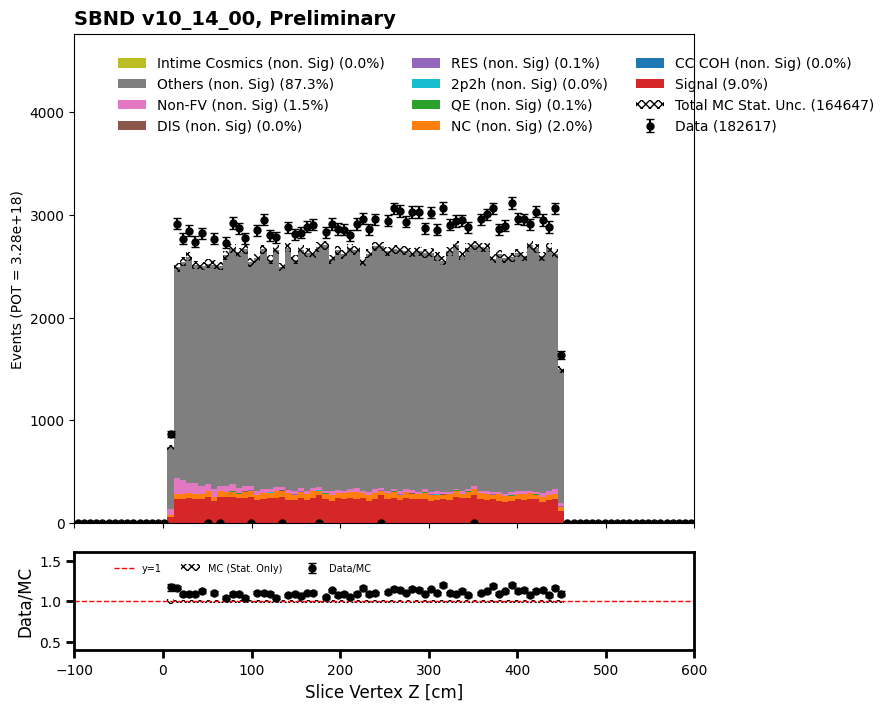

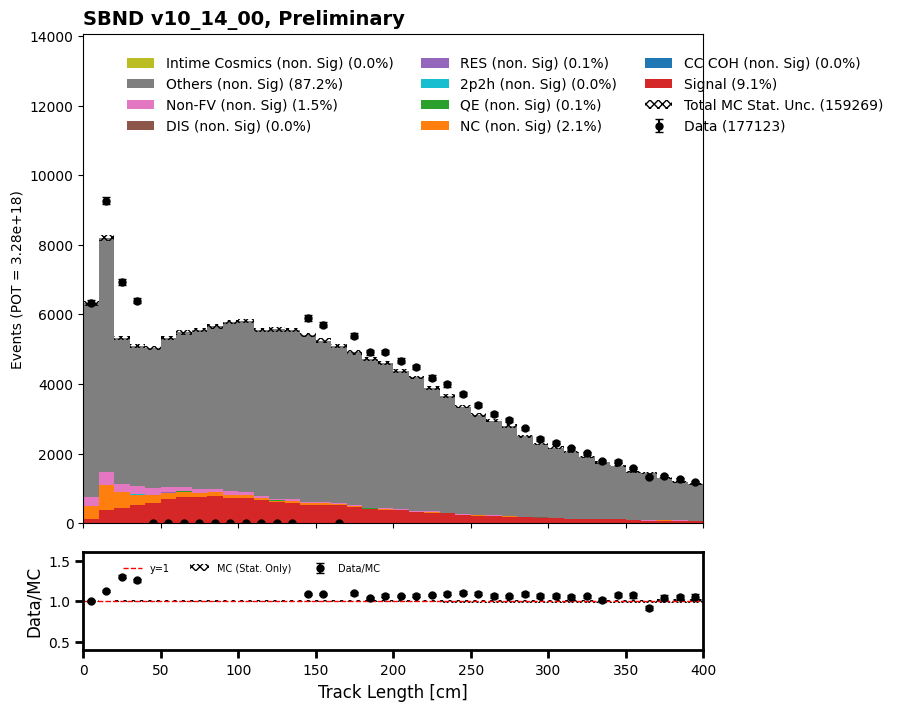

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


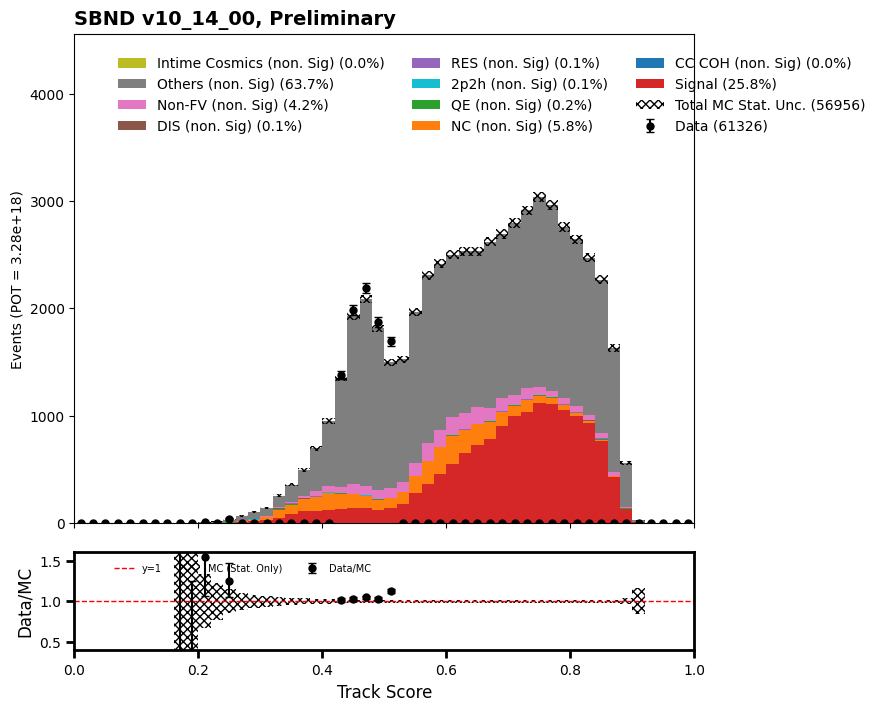

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

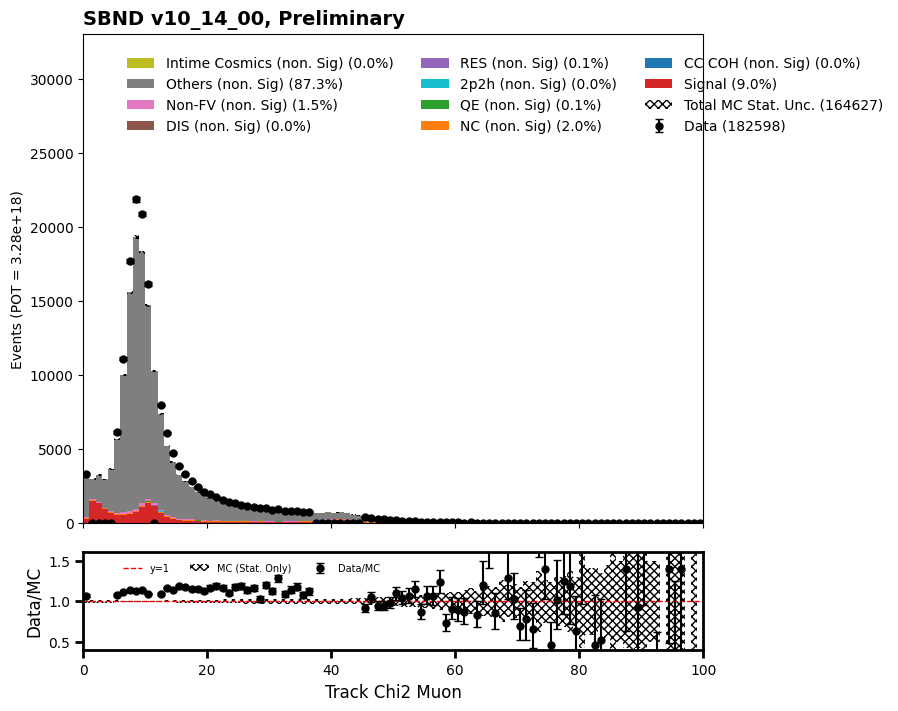

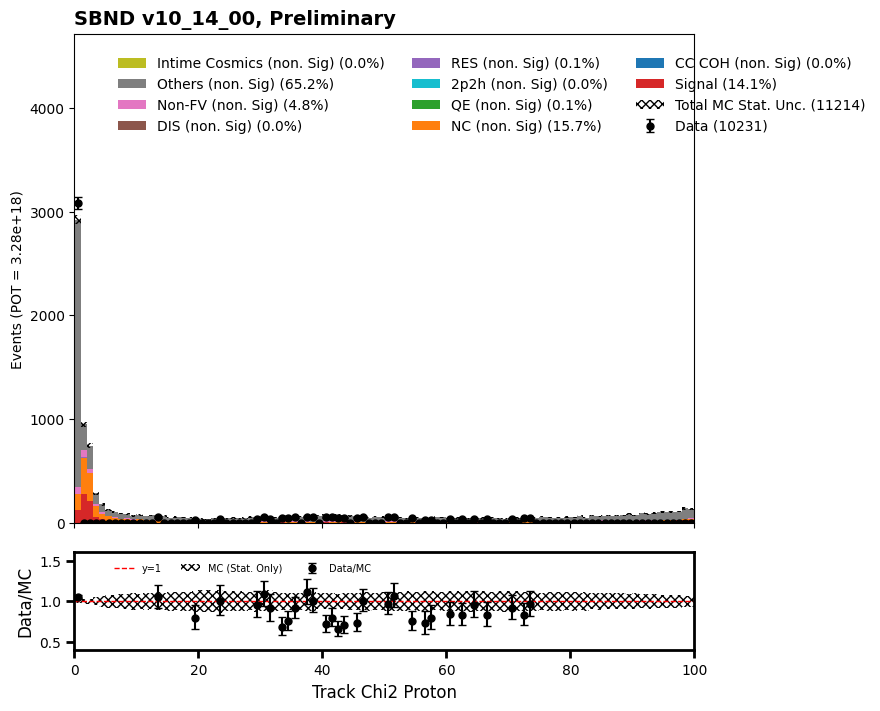

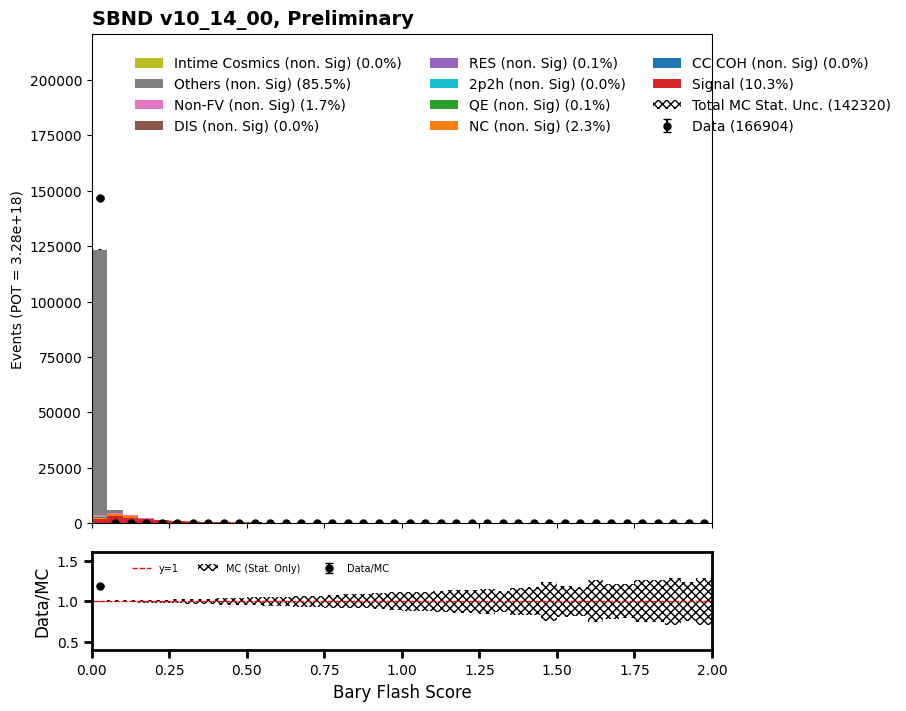

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

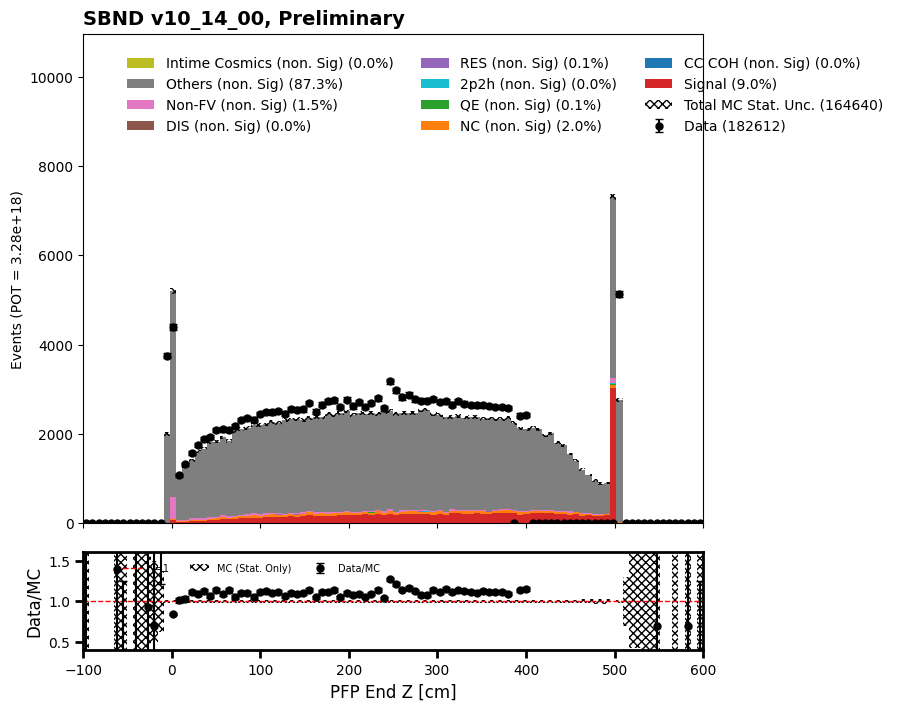

In [48]:
#Vertex Cut

mc_bnb_cosmic_dfs["evt"] = mc_bnb_cosmic_dfs["evt"][InFV(mc_bnb_cosmic_dfs["evt"].slc.vertex)]
data_offbeam_light_dfs["evt"] = data_offbeam_light_dfs["evt"][InFV(data_offbeam_light_dfs["evt"].slc.vertex)]
data_bnb_light_dfs["evt"] = data_bnb_light_dfs["evt"][InFV(data_bnb_light_dfs["evt"].slc.vertex)]

#plot

draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"], data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "a_b_vtxfvcut")

In [50]:
purity = 14854.9189453125/164646.974091053
efficiency = 14854.9189453125/15446.2763671875
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  9.02 % and efficiency =  96.17 %


/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


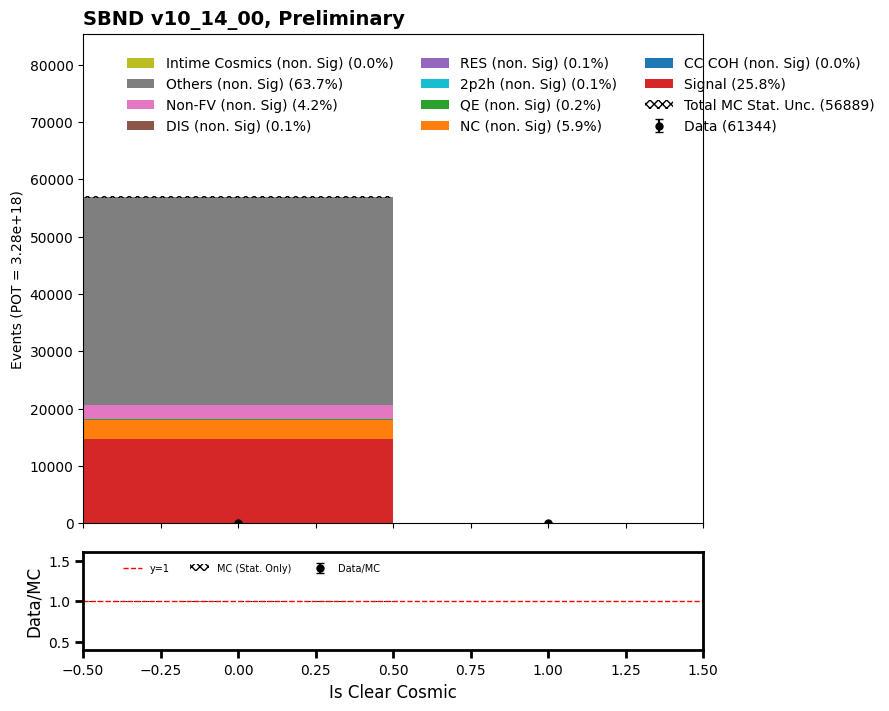

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


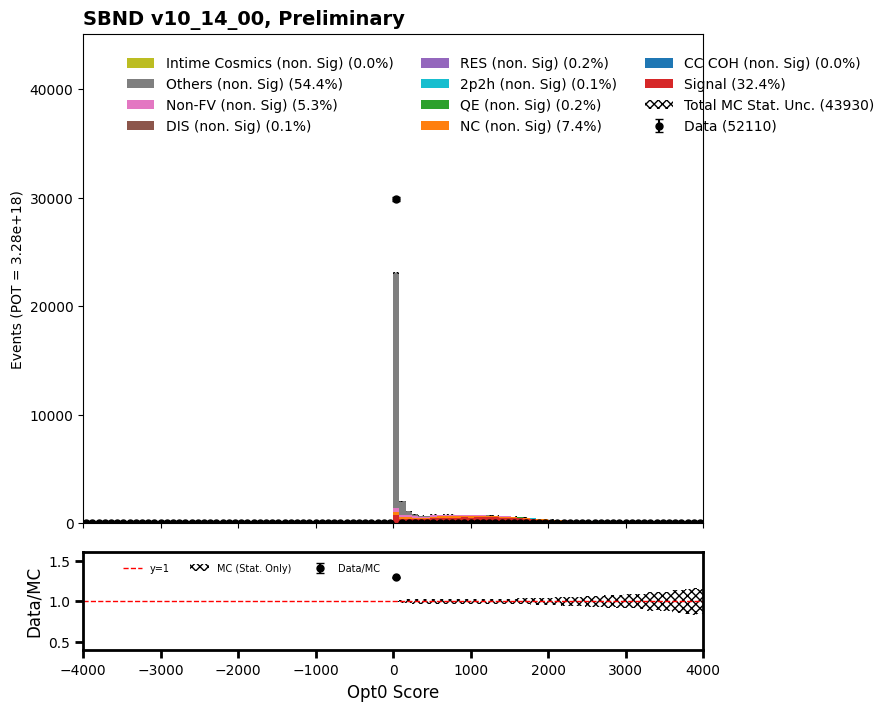

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


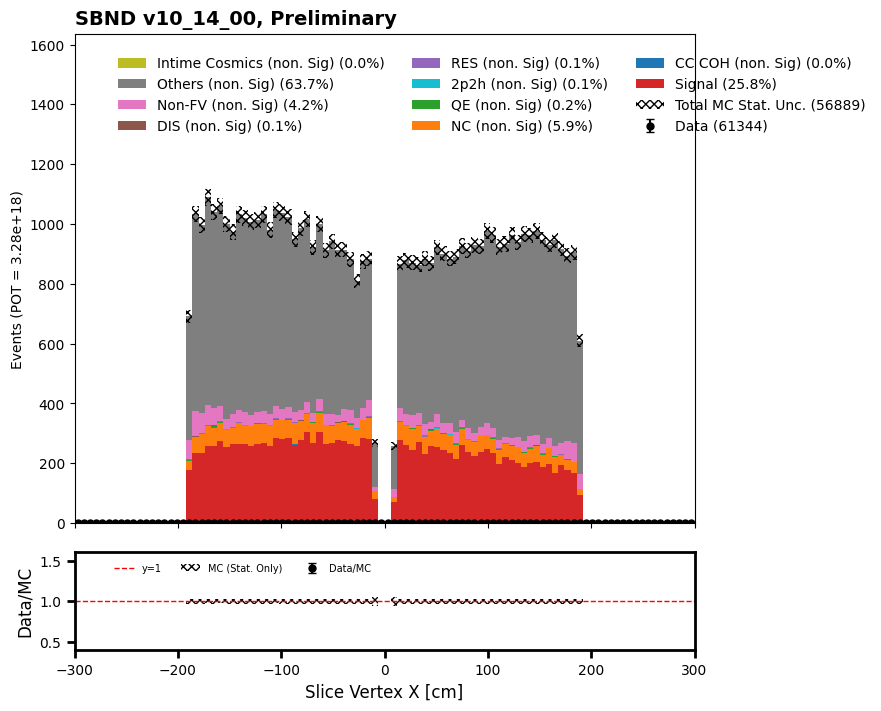

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


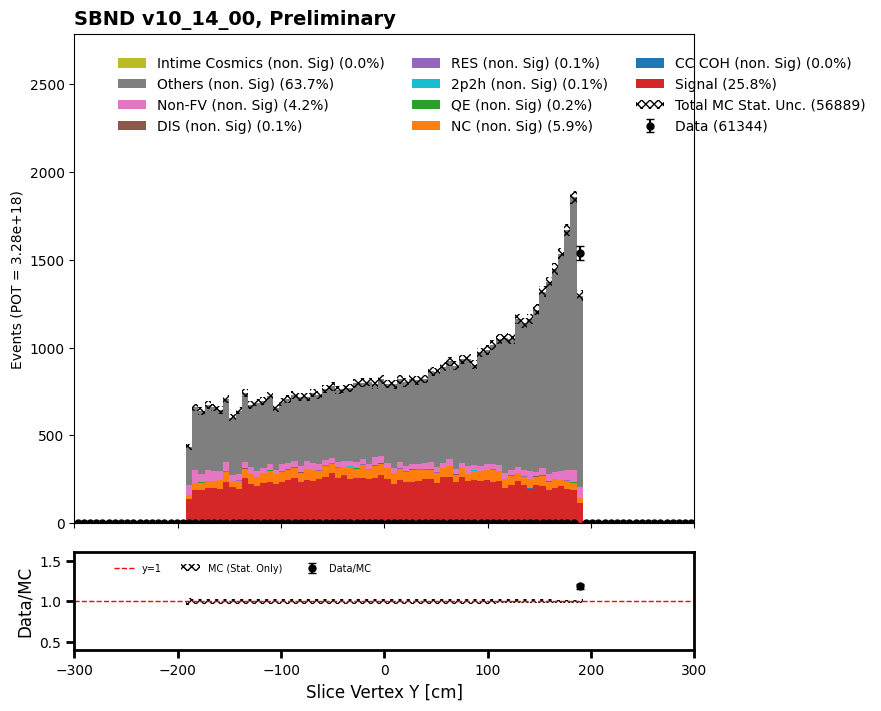

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


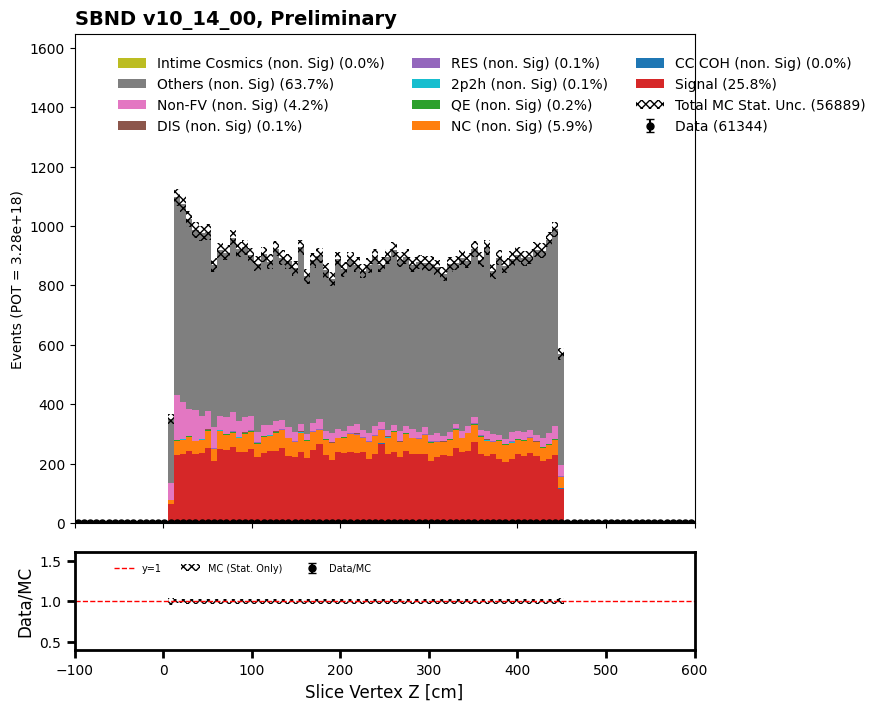

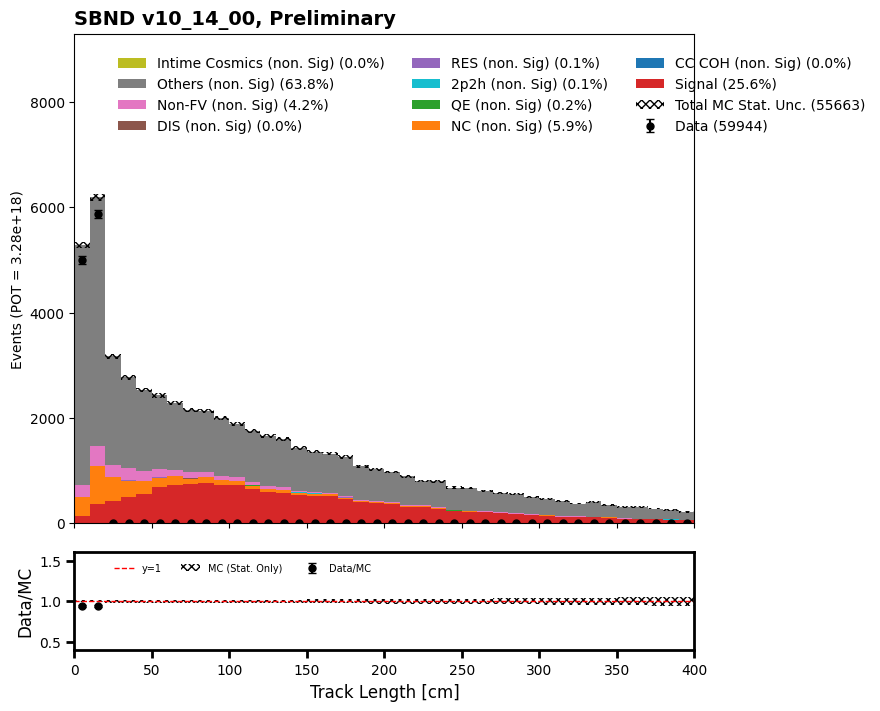

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


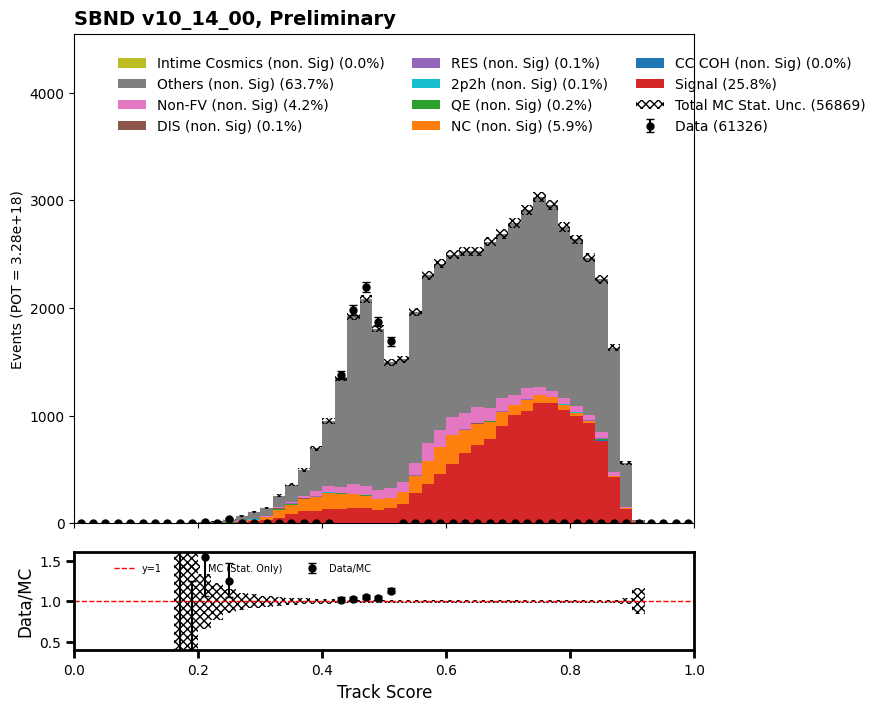

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

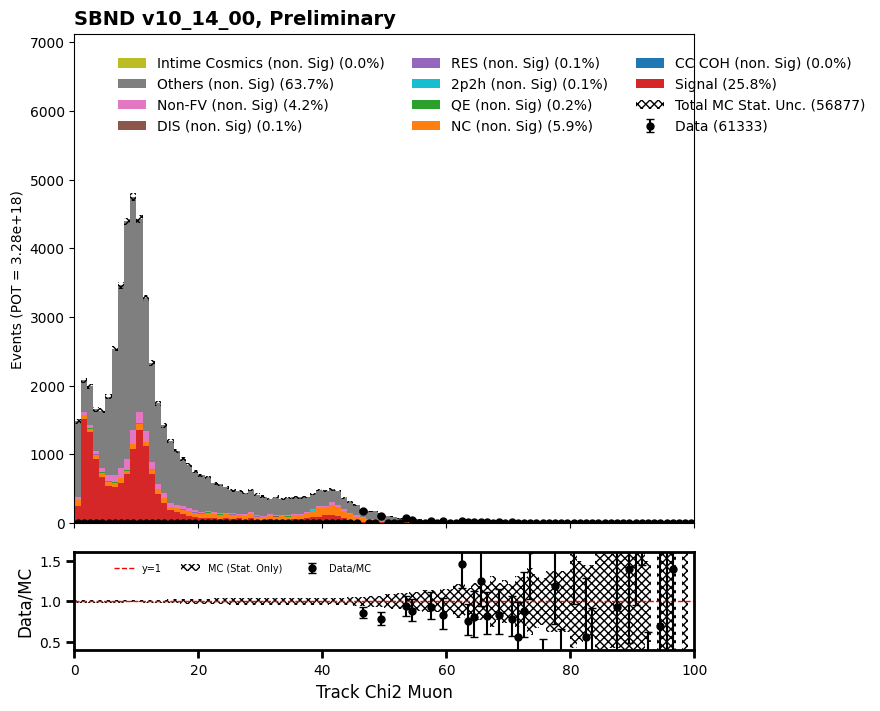

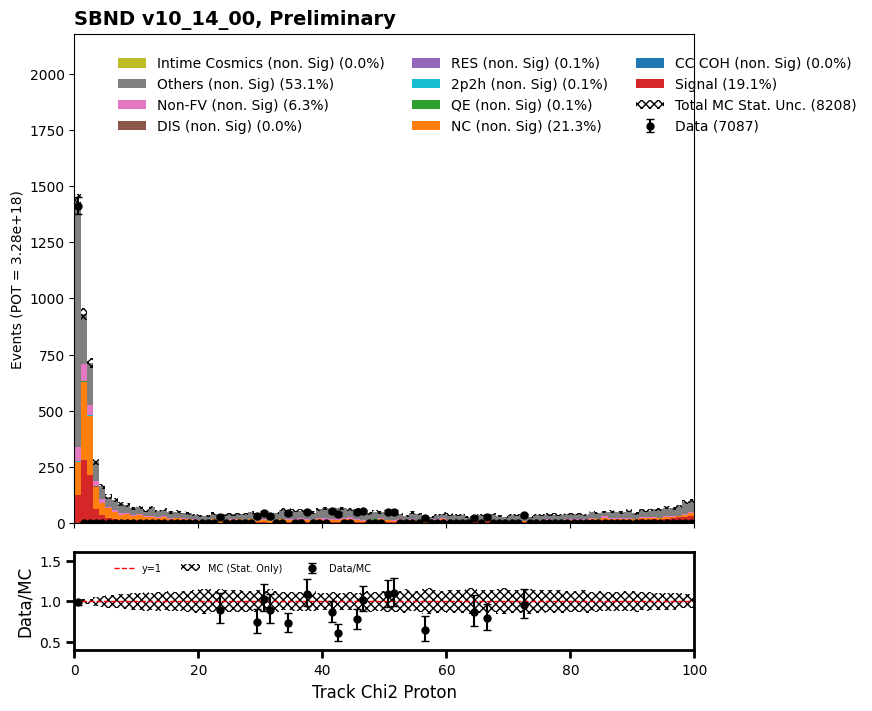

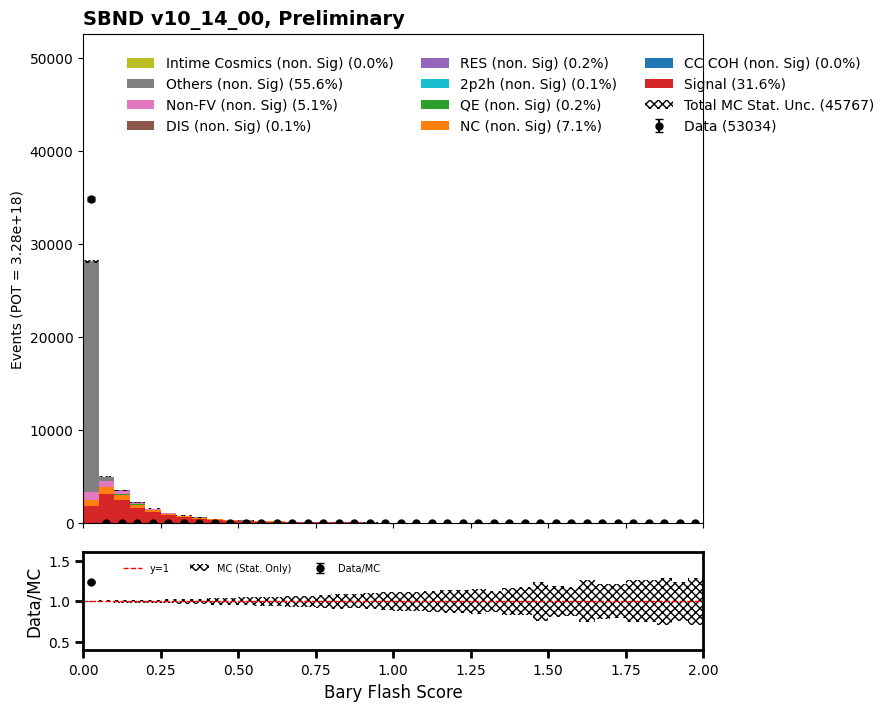

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

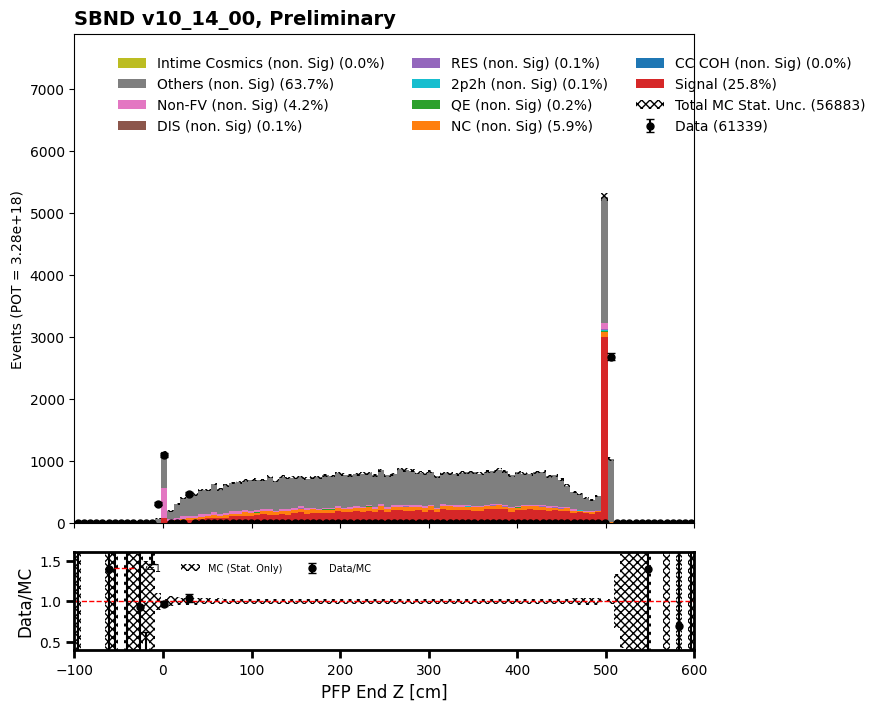

In [49]:
#Clear cosmic

mc_bnb_cosmic_dfs["evt"] = mc_bnb_cosmic_dfs["evt"][mc_bnb_cosmic_dfs["evt"].slc.is_clear_cosmic == 0]
data_offbeam_light_dfs["evt"] = data_offbeam_light_dfs["evt"][data_offbeam_light_dfs["evt"].slc.is_clear_cosmic == 0]
data_bnb_light_dfs["evt"] = data_bnb_light_dfs["evt"][data_bnb_light_dfs["evt"].slc.is_clear_cosmic == 0]


draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"], data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "a_vtx_fv_and_not_clear_cosmic")

In [54]:
purity = 14687.1884765625/56888.76689577103
efficiency = 14687.1884765625/15446.2763671875
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  25.82 % and efficiency =  95.09 %


In [50]:
def get_evt_nmuon_mask(mask, df):
    sel_idx = mask[mask].index
    #pairs = df.index.droplevel([-2, -1])
    pairs = df.index
    mask2 = pairs.isin(sel_idx)
    return mask2

In [51]:
def make_nmuon_filtered_df(df):
    nmuon_cut = df[(df.pfp.trackScore > 0.6) & (df.pfp.trk.len > 32) & (df.pfp.trk.chi2pid.I2.chi2_muon < 20) & (df.pfp.trk.chi2pid.I2.chi2_proton > 90)].sort_values(df.pfp.index.names[:-1] + [('pfp','trk','len','','','')], ascending=True).groupby(level=[0,1]).nth(-1)
    nmuon_mask = (nmuon_cut == True)

    mc_bnb_cosmic_evt_nmuon_mask = get_evt_nmuon_mask(nmuon_mask, df)
    df[('lead_track_nmuon', '', '', '', '', '')] = mc_bnb_cosmic_evt_nmuon_mask

    valid_slices = df.lead_track_nmuon[df.lead_track_nmuon == True].index

    filtered_df = df.loc[df.index.droplevel('rec.slc.reco.pfp..index').isin(valid_slices.droplevel('rec.slc.reco.pfp..index'))]

    return filtered_df

In [52]:
filtered_df = make_nmuon_filtered_df(mc_bnb_cosmic_dfs["evt"])
filtered_dfb = make_nmuon_filtered_df(data_offbeam_light_dfs["evt"])
filtered_dfc = make_nmuon_filtered_df(data_bnb_light_dfs["evt"])

In [53]:
mc_bnb_cosmic_dfs["evt"] = filtered_df
data_offbeam_light_dfs["evt"] = filtered_dfb
data_bnb_light_dfs["evt"] = filtered_dfc

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


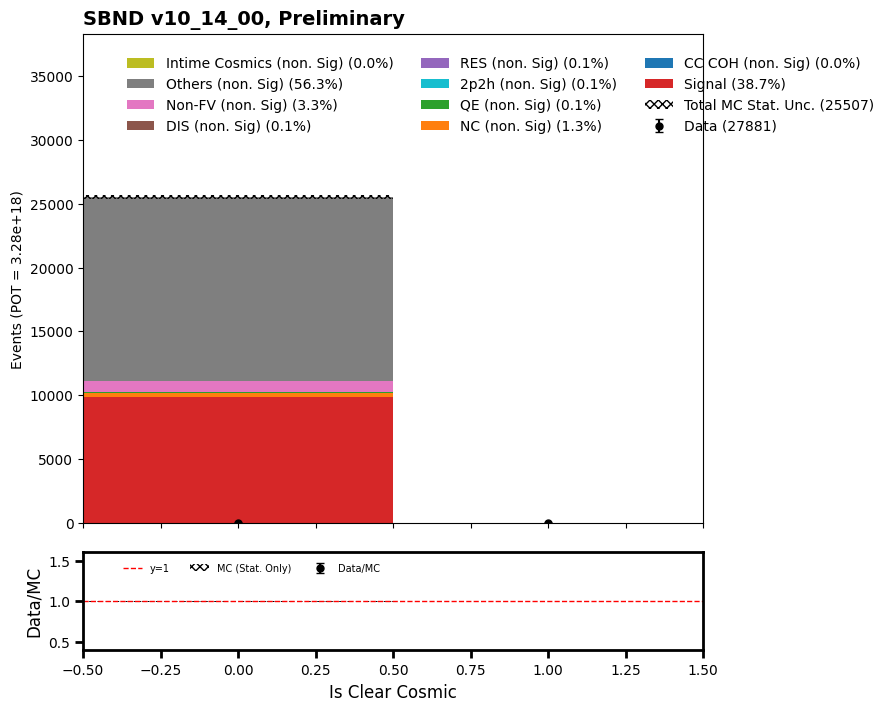

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


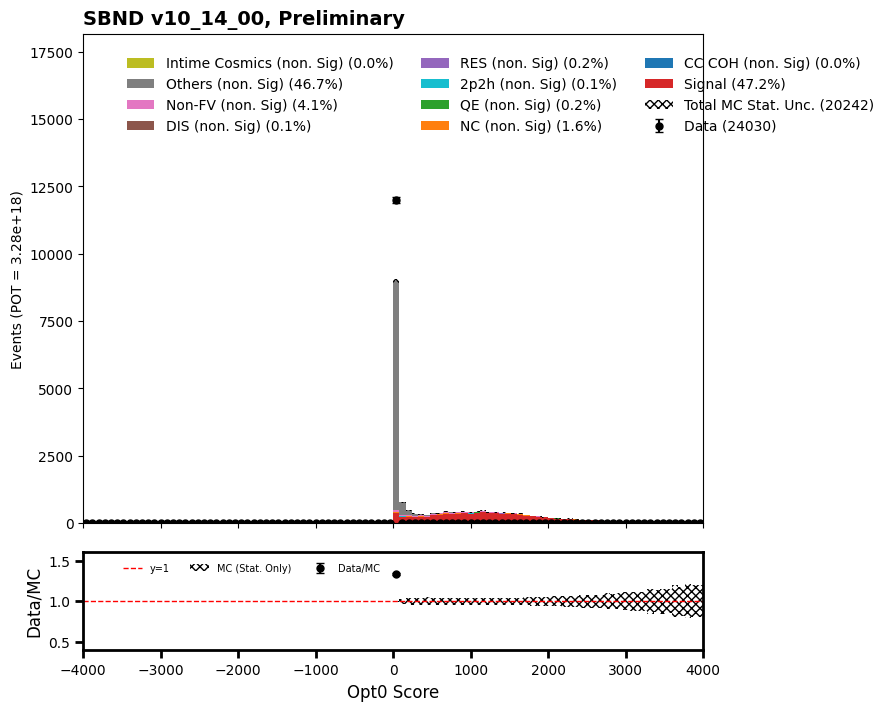

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


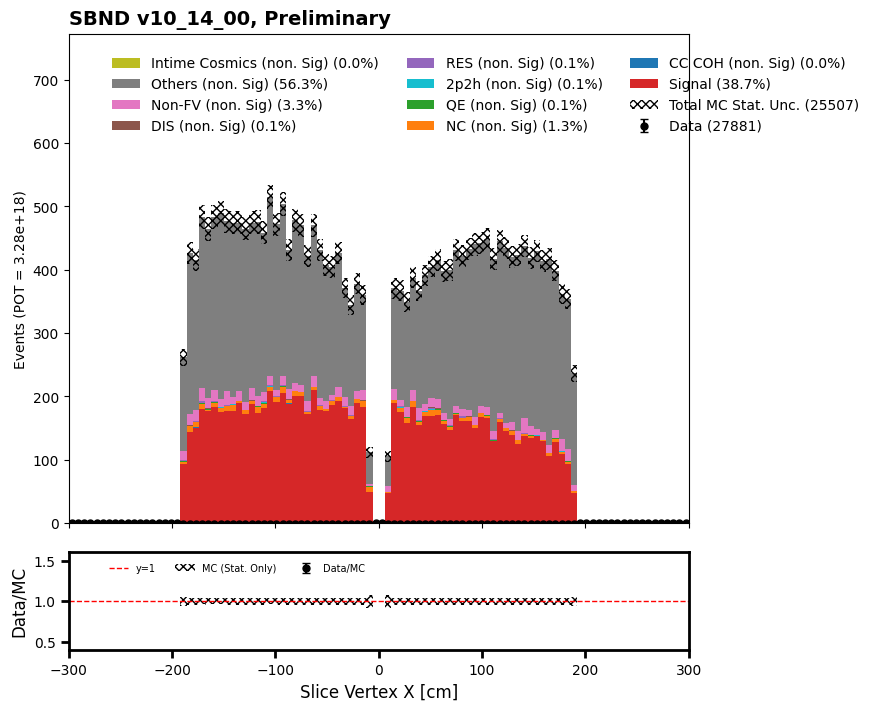

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


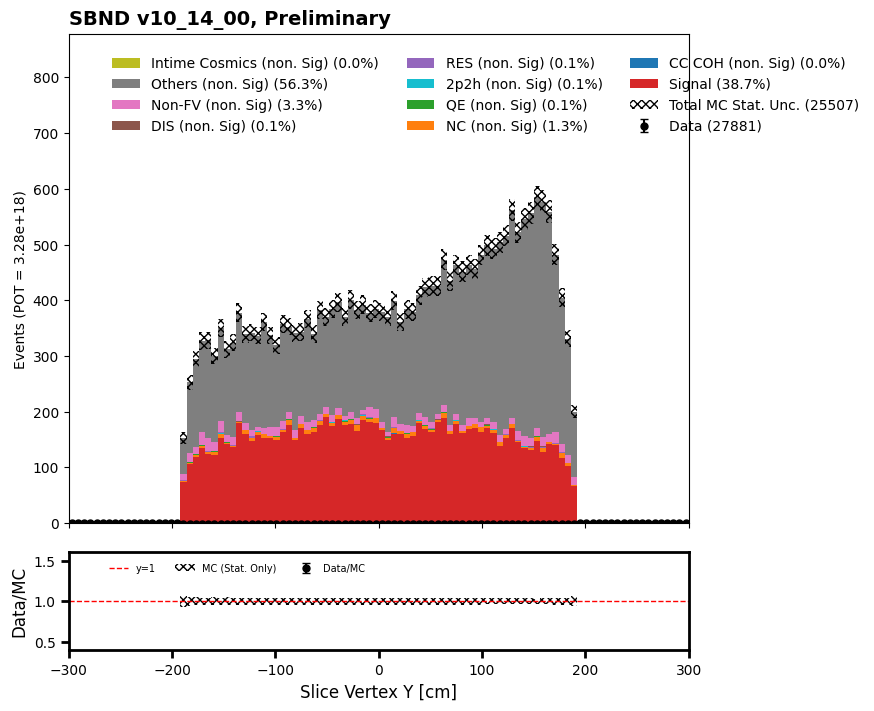

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


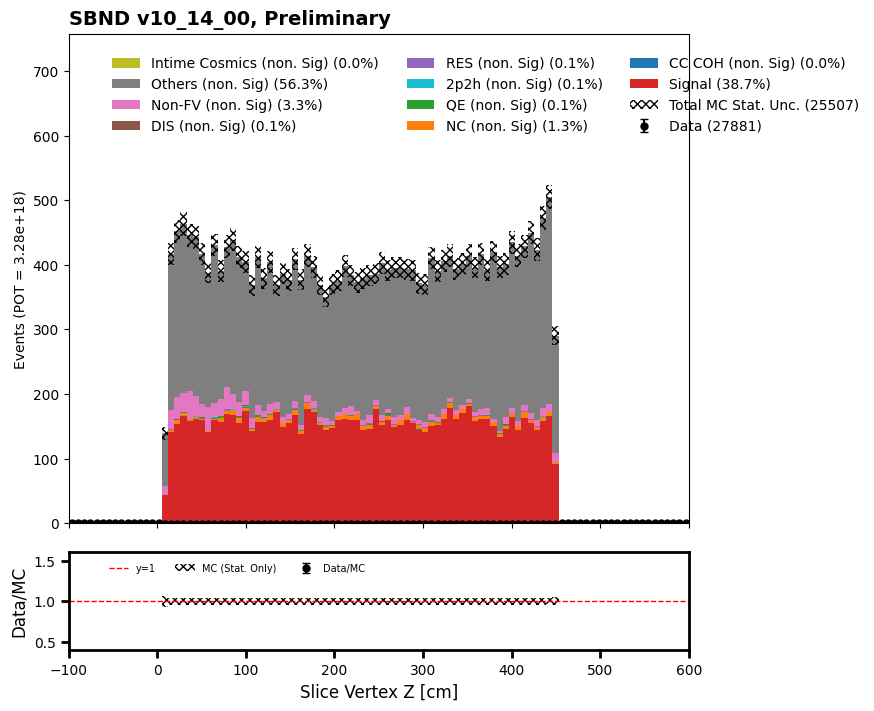

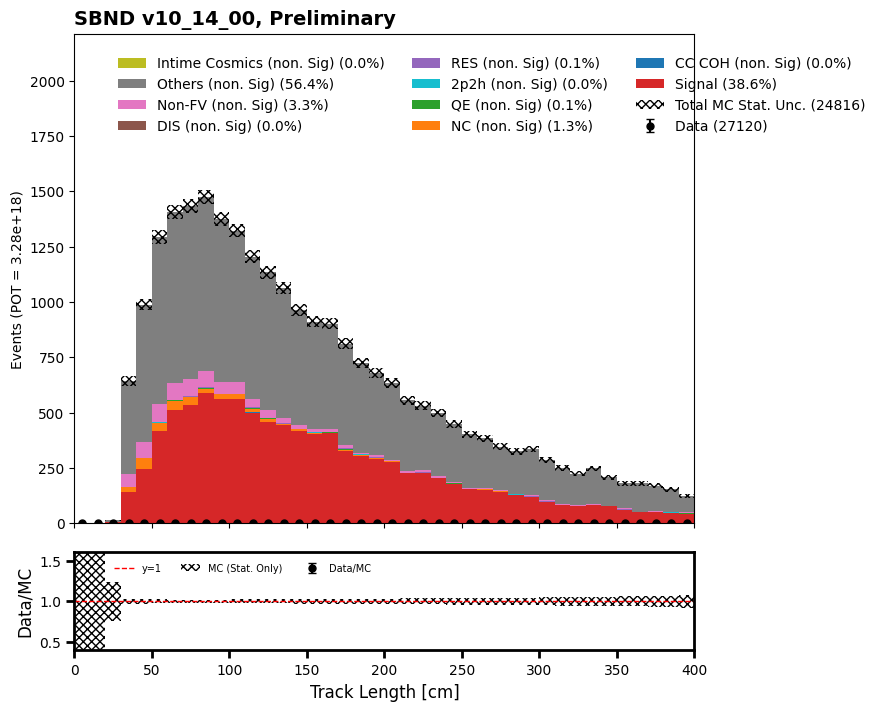

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


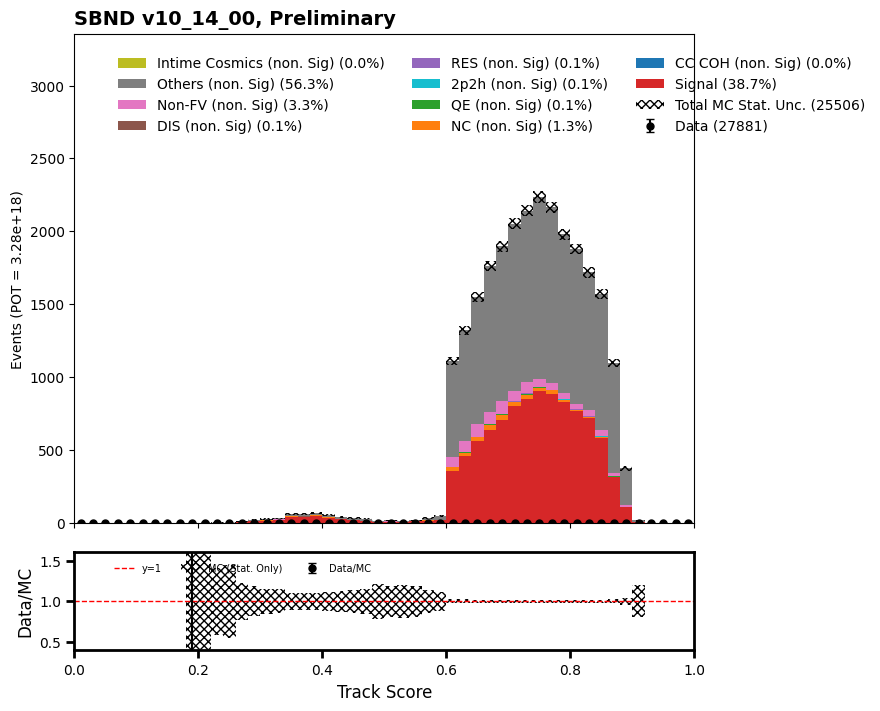

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

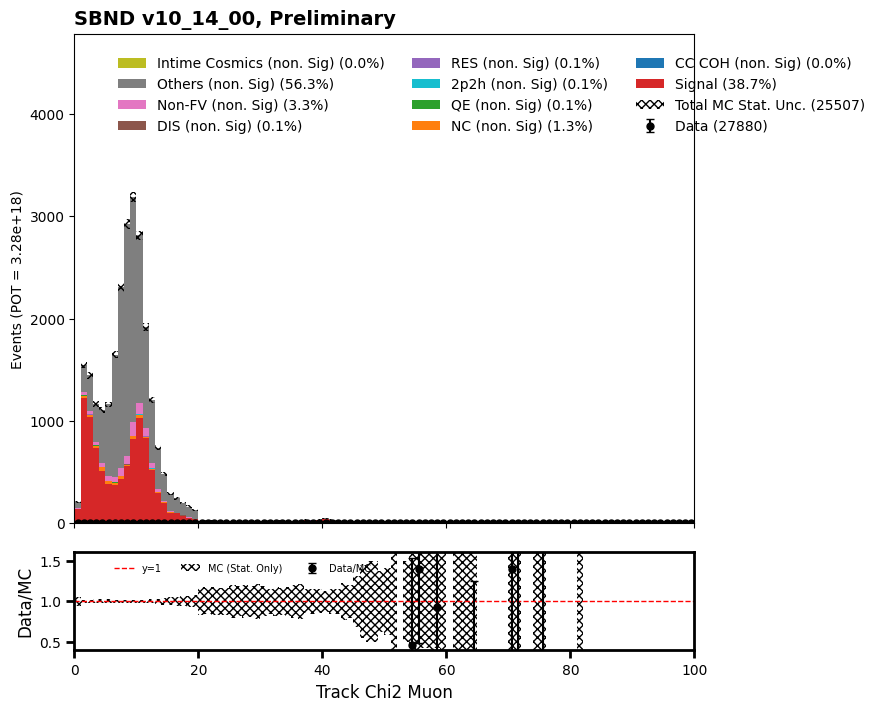

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

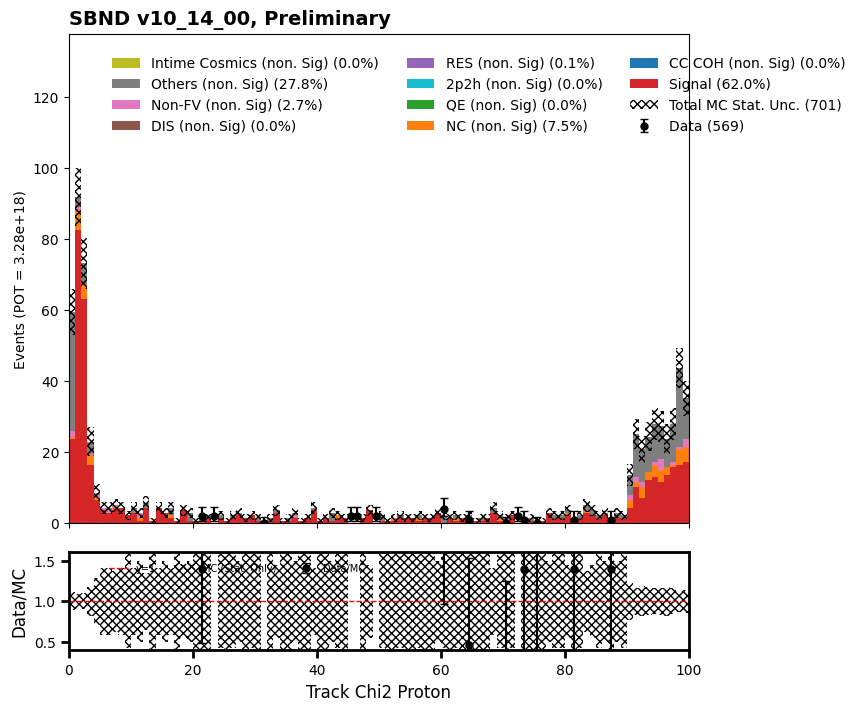

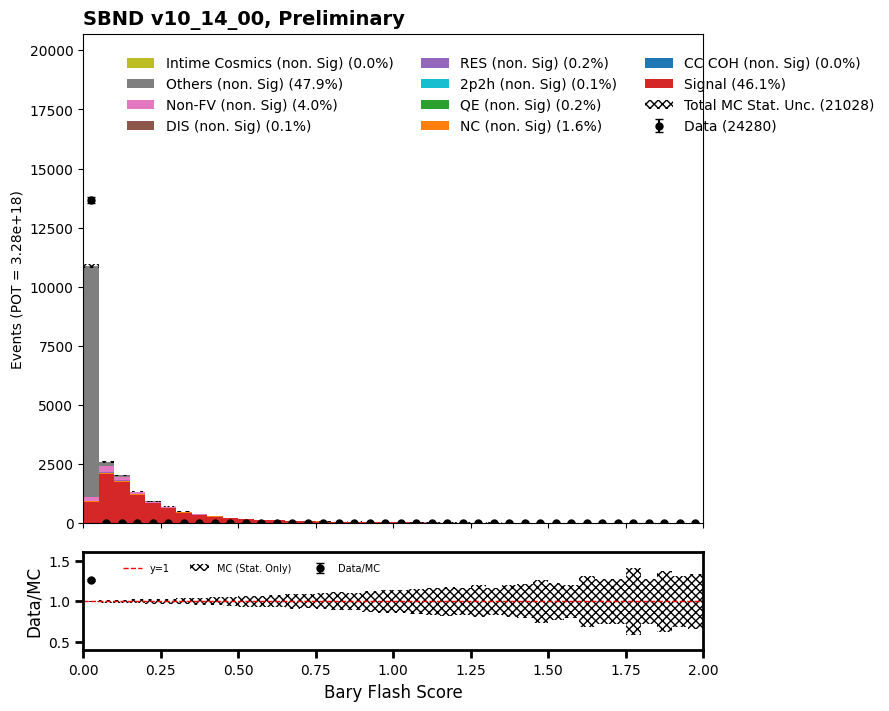

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

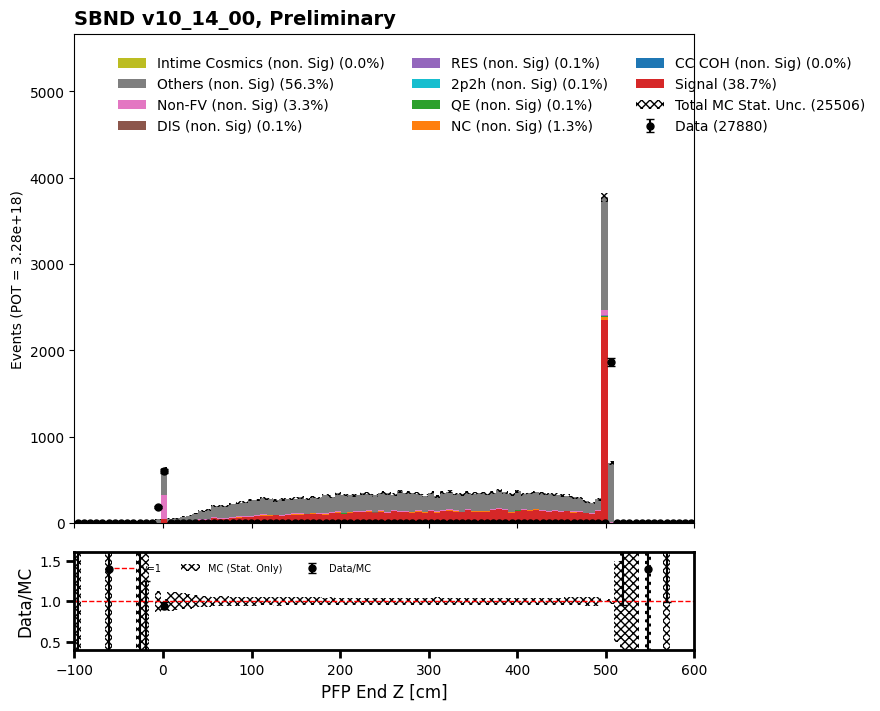

In [54]:
#Has muon candidate

#mc_bnb_cosmic_dfs["evt"] = mc_bnb_cosmic_dfs["evt"][HasMuonCandidate(mc_bnb_cosmic_dfs["evt"])]
#data_offbeam_light_dfs["evt"] = data_offbeam_light_dfs["evt"][HasMuonCandidate(data_offbeam_light_dfs["evt"])]
#data_bnb_light_dfs["evt"] = data_bnb_light_dfs["evt"][HasMuonCandidate(data_bnb_light_dfs["evt"])]

draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"],  data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "a_vtx_fv_and_not_clear_cosmic_nu_score")

In [59]:
purity = 9866.7294921875/25506.577800631523
efficiency = 9866.7294921875/15446.2763671875
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  38.68 % and efficiency =  63.88 %


/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


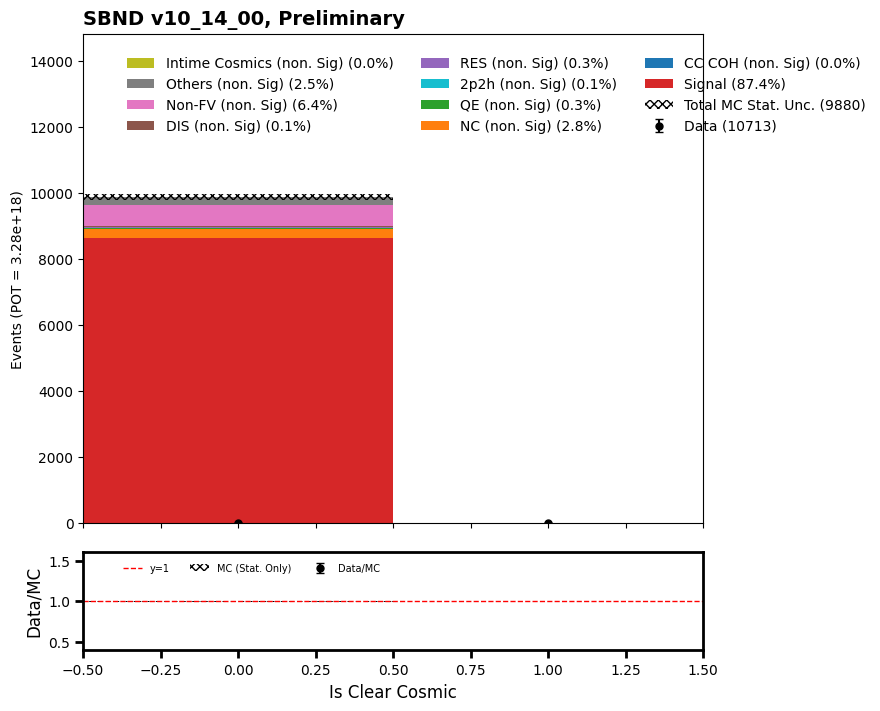

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


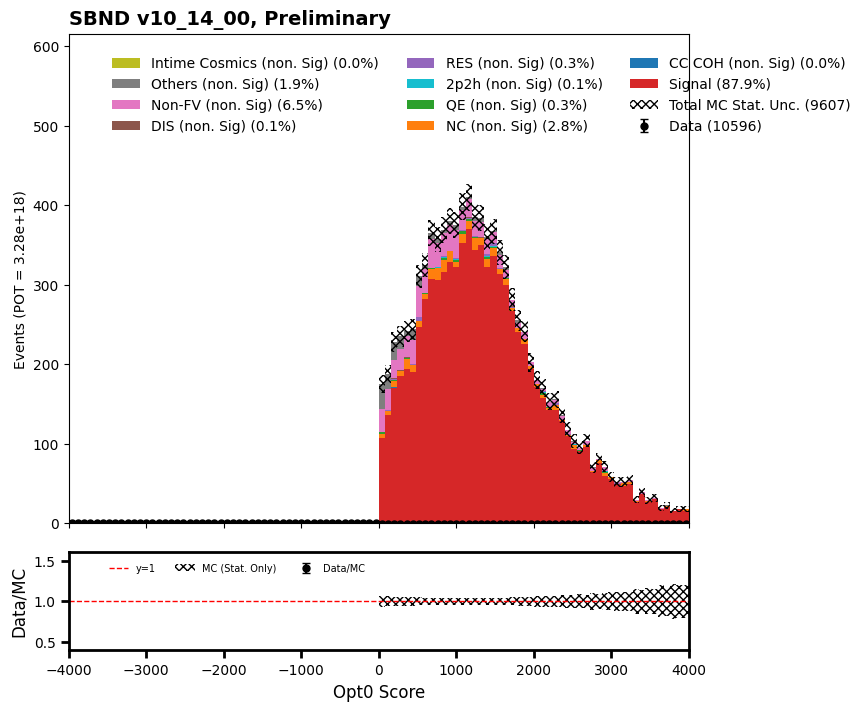

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


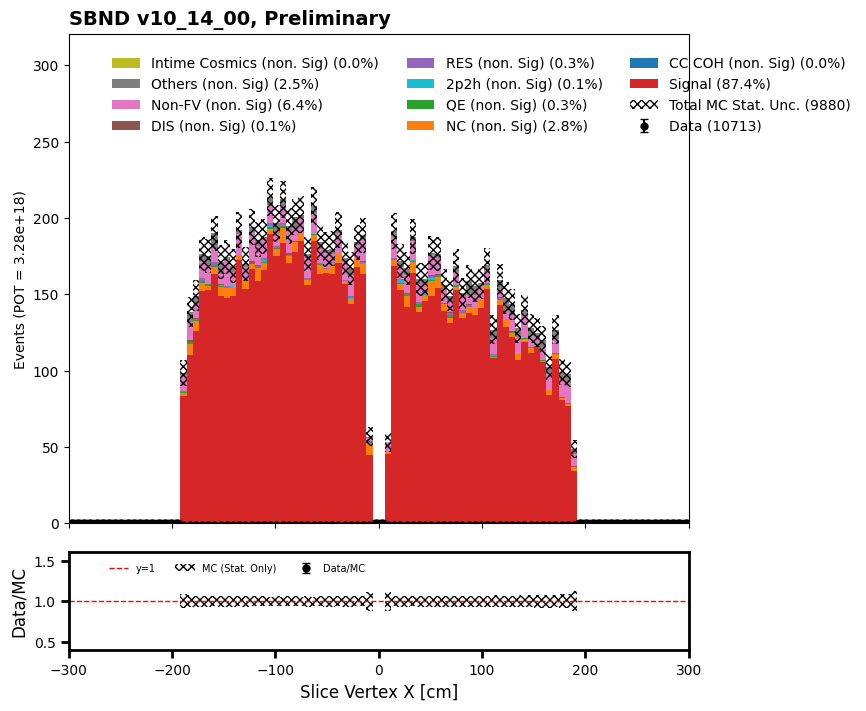

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


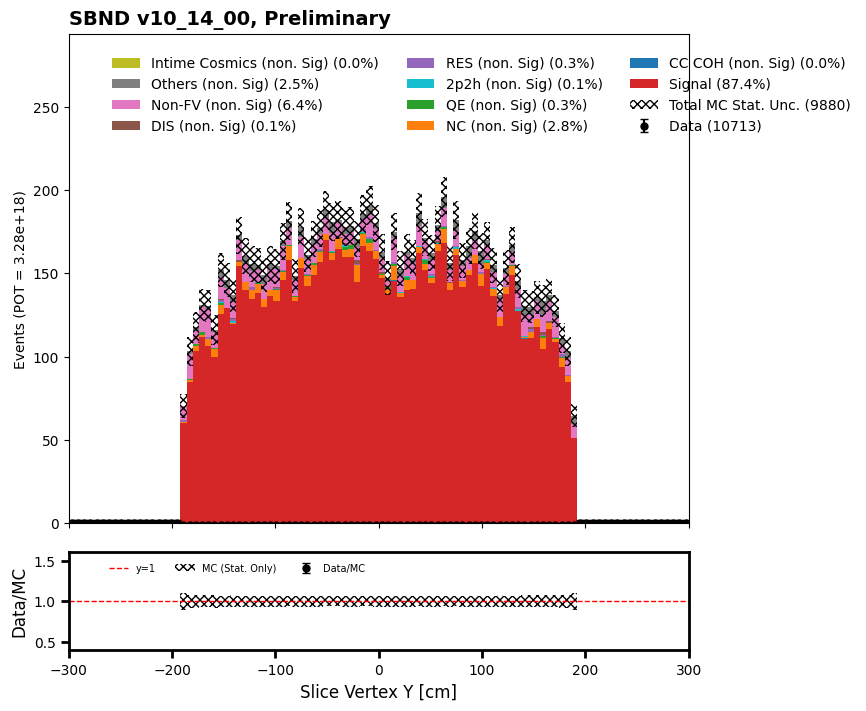

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


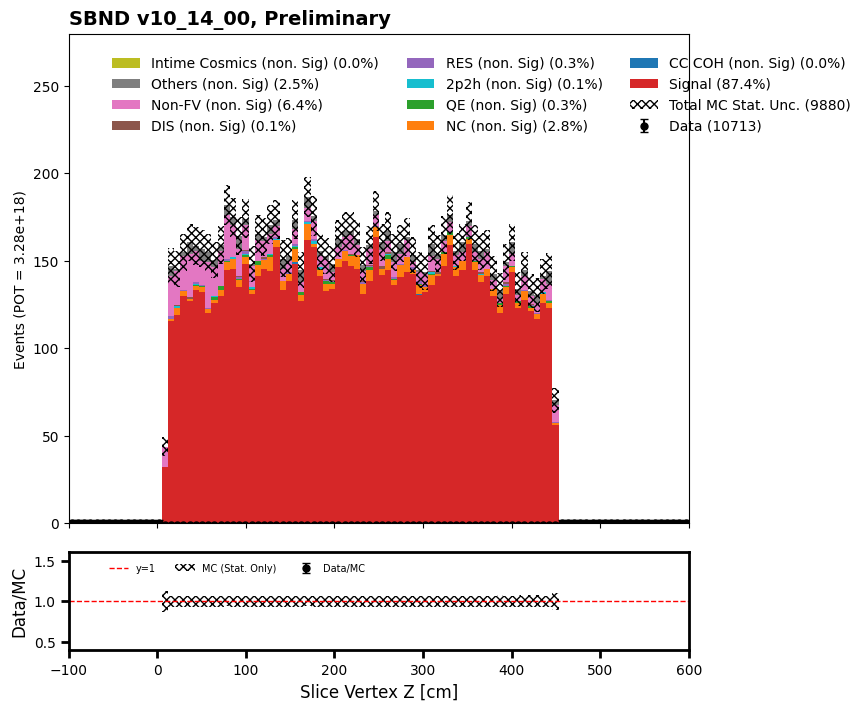

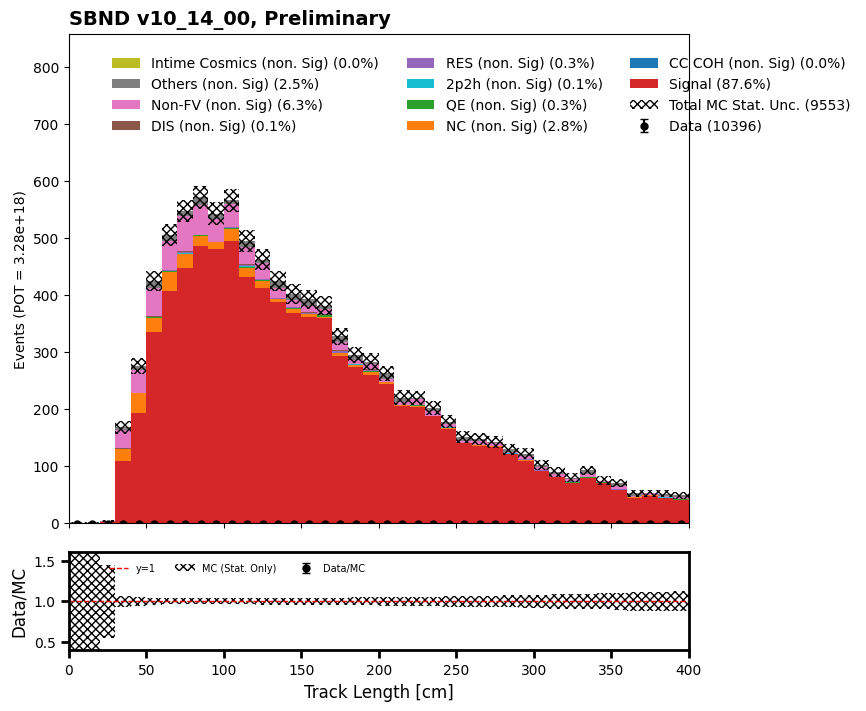

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


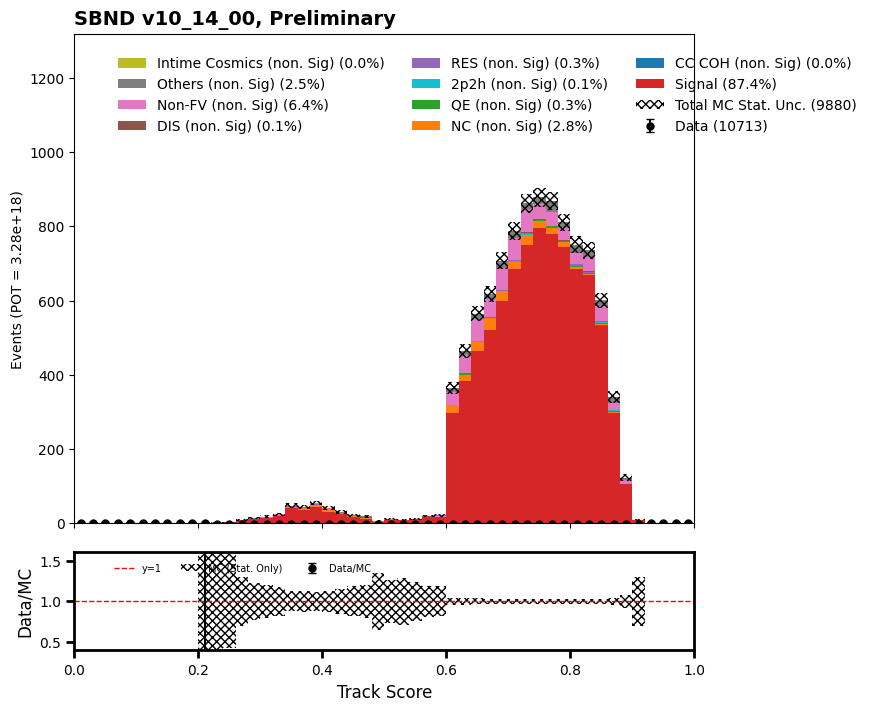

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

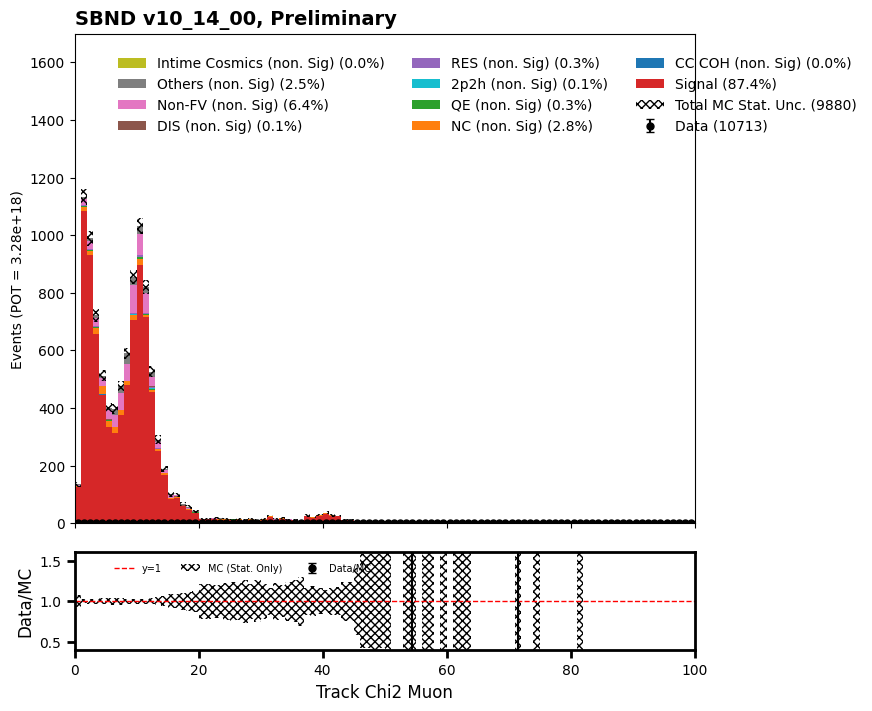

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

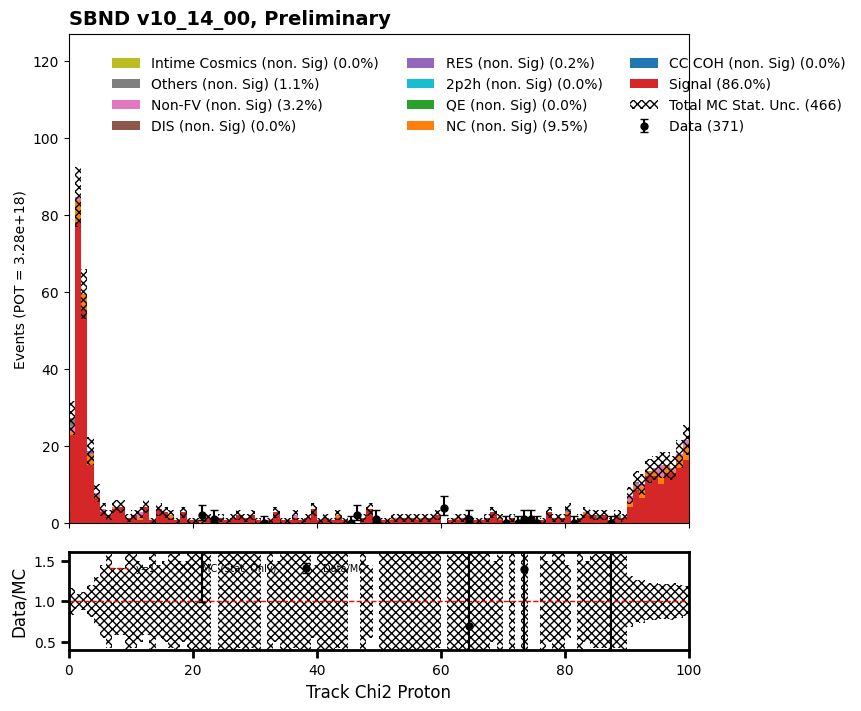

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


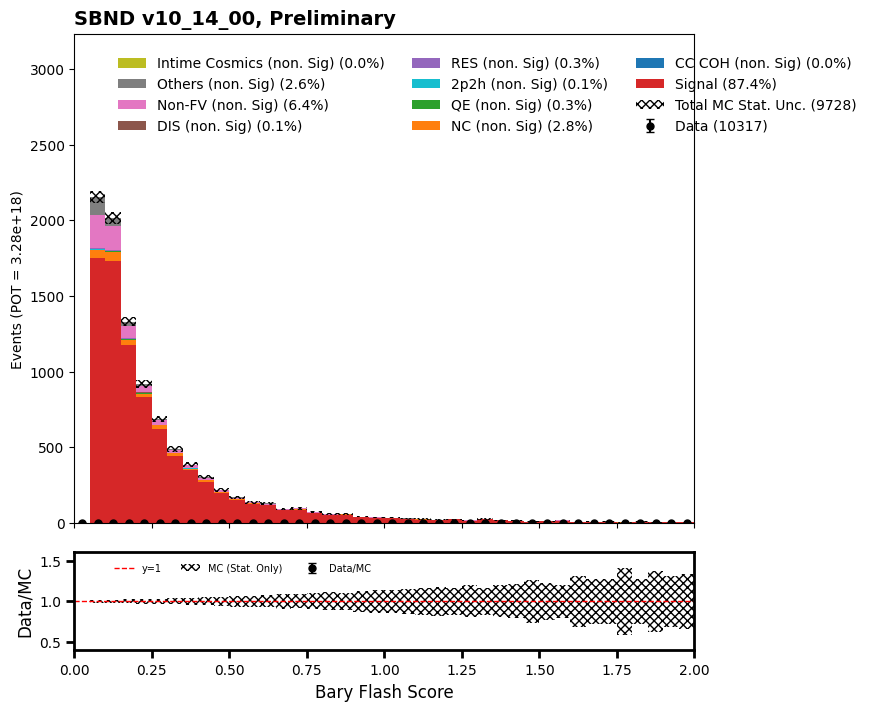

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

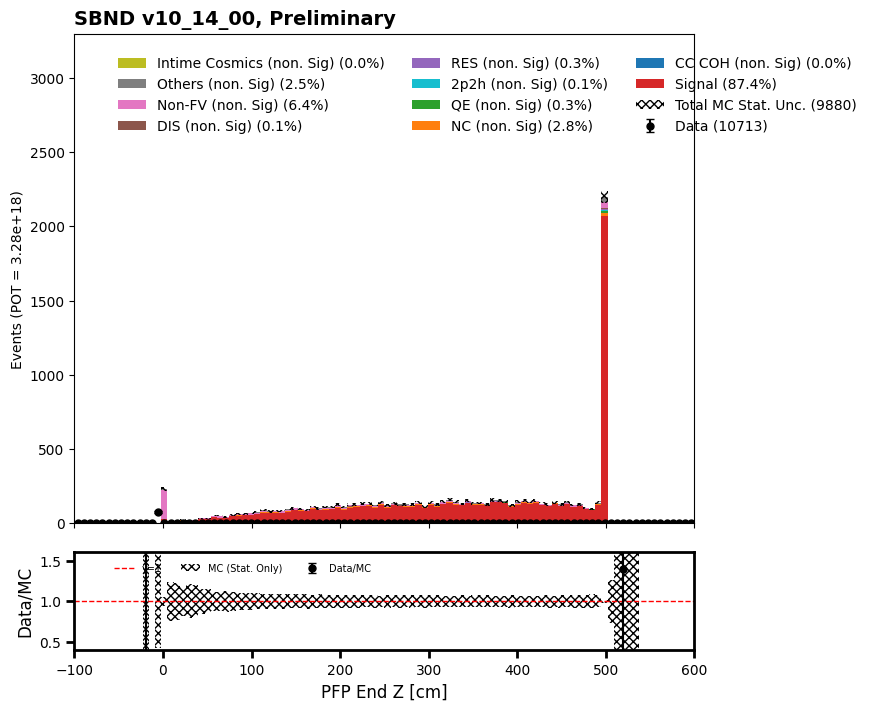

In [55]:
#bary score

mc_bnb_cosmic_dfs["evt"] = mc_bnb_cosmic_dfs["evt"][ (mc_bnb_cosmic_dfs["evt"].slc.barycenterFM.score > 0.06)]
data_offbeam_light_dfs["evt"] = data_offbeam_light_dfs["evt"][(data_offbeam_light_dfs["evt"].slc.barycenterFM.score > 0.06)]
data_bnb_light_dfs["evt"] = data_bnb_light_dfs["evt"][(data_bnb_light_dfs["evt"].slc.barycenterFM.score > 0.06)]

draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"], data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "a_vtx_fv_and_not_clear_cosmic_nu_score_bscore")

In [61]:
purity = 8637.4228515625/9880.391903758049
efficiency = 8637.4228515625/15446.2763671875
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  87.42 % and efficiency =  55.92 %


In [56]:
def make_nmuonz_filtered_df(df):
    nmuonz_cut = df[(df.pfp.trackScore > 0.6) & (df.pfp.trk.len > 32) & (df.pfp.trk.chi2pid.I2.chi2_muon < 20) & (df.pfp.trk.chi2pid.I2.chi2_proton > 90) & (df.pfp.trk.end.z > 6)].sort_values(df.pfp.index.names[:-1] + [('pfp','trk','end','z','','')], ascending=True).groupby(level=[0,1]).nth(-1)
    nmuonz_mask = (nmuonz_cut == True)

    mc_bnb_cosmic_evt_nmuonz_mask = get_evt_nmuon_mask(nmuonz_mask, df)
    df[('lead_track_nmuonz', '', '', '', '', '')] = mc_bnb_cosmic_evt_nmuonz_mask

    valid_slicesz = df.lead_track_nmuonz[df.lead_track_nmuonz == True].index

    filtered_dfz = df.loc[df.index.droplevel('rec.slc.reco.pfp..index').isin(valid_slicesz.droplevel('rec.slc.reco.pfp..index'))]

    return filtered_dfz

In [57]:
filtered_dfz = make_nmuonz_filtered_df(mc_bnb_cosmic_dfs["evt"])
filtered_dfzb = make_nmuonz_filtered_df(data_offbeam_light_dfs["evt"])
filtered_dfzc = make_nmuonz_filtered_df(data_bnb_light_dfs["evt"])

/tmp/ipykernel_1482/1187105749.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[('lead_track_nmuonz', '', '', '', '', '')] = mc_bnb_cosmic_evt_nmuonz_mask
/tmp/ipykernel_1482/1187105749.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[('lead_track_nmuonz', '', '', '', '', '')] = mc_bnb_cosmic_evt_nmuonz_mask
/tmp/ipykernel_1482/1187105749.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

In [58]:
mc_bnb_cosmic_dfs["evt"] = filtered_dfz
data_offbeam_light_dfs["evt"] = filtered_dfzb
data_bnb_light_dfs["evt"] = filtered_dfzc

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


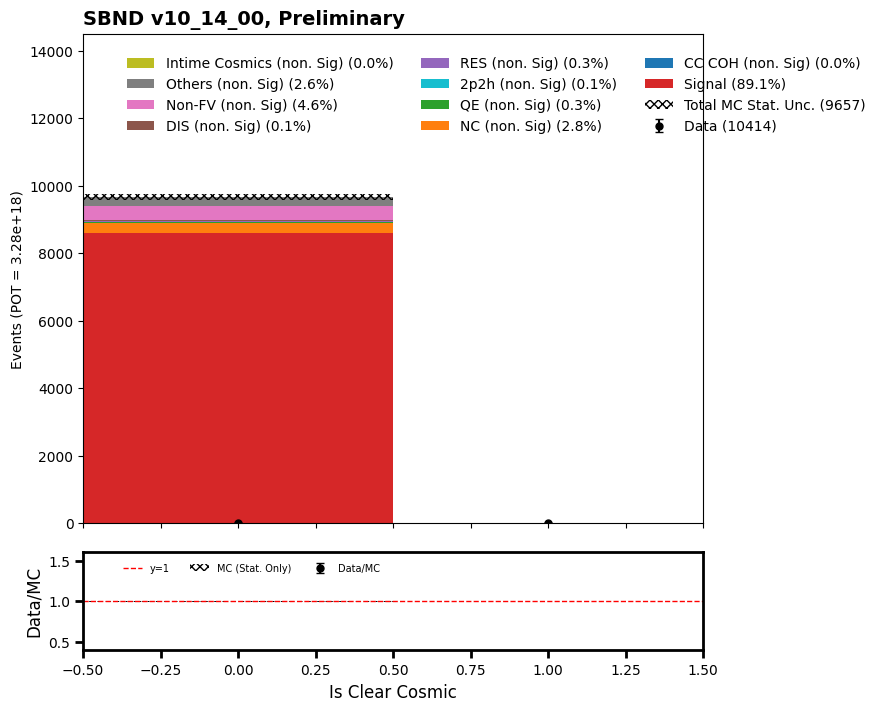

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


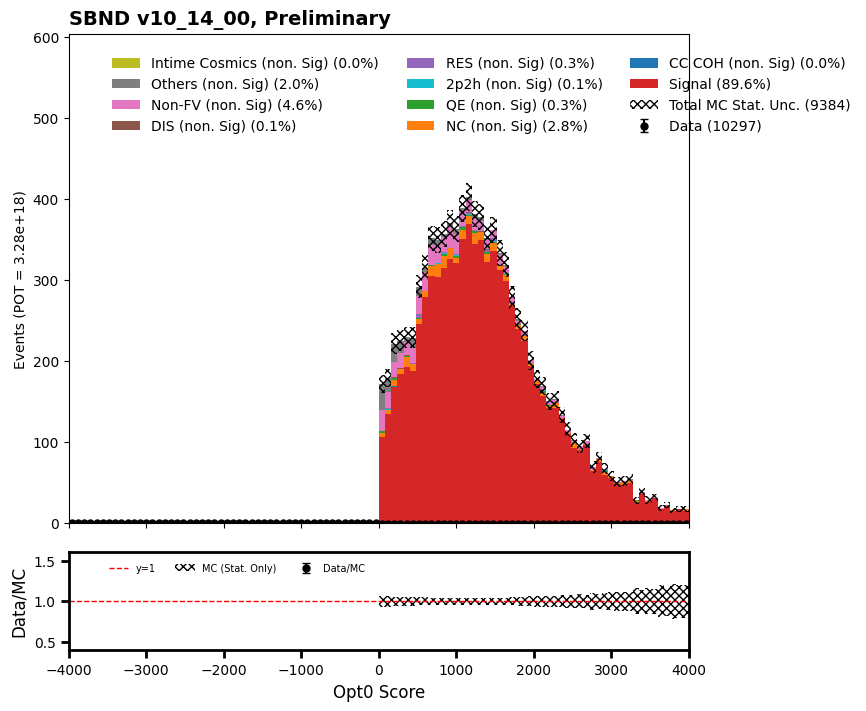

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


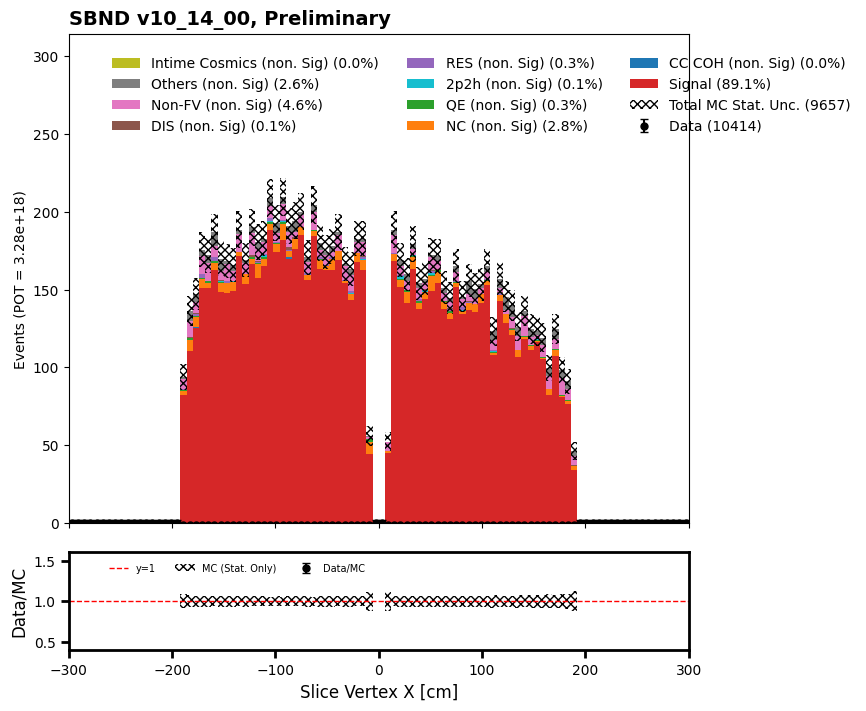

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


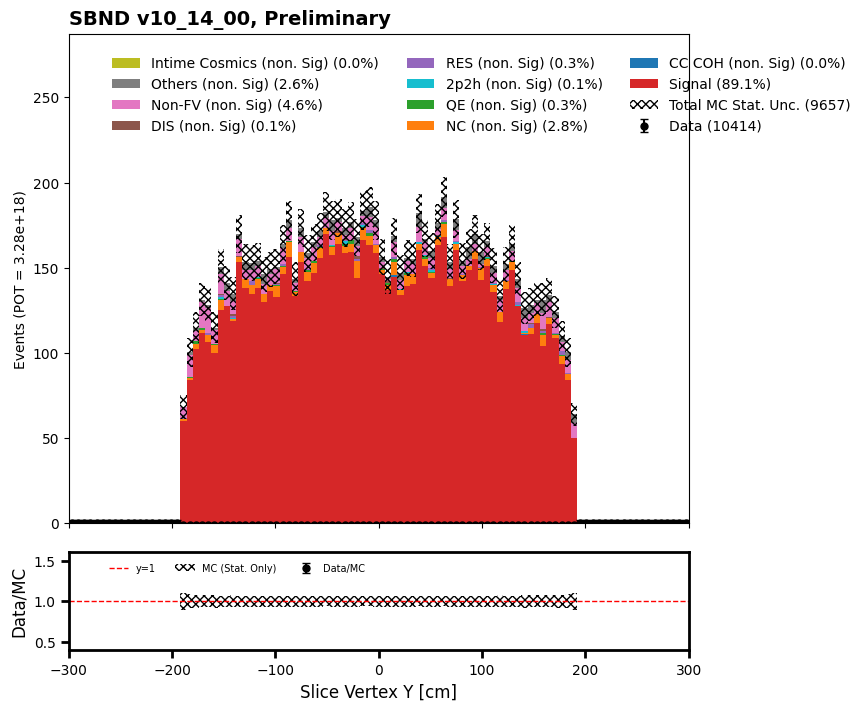

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


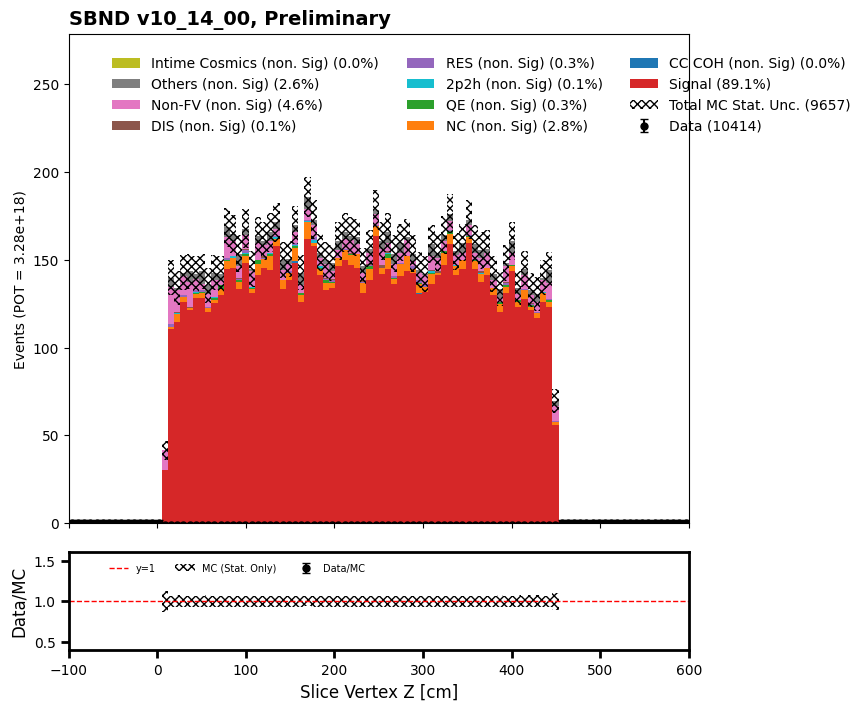

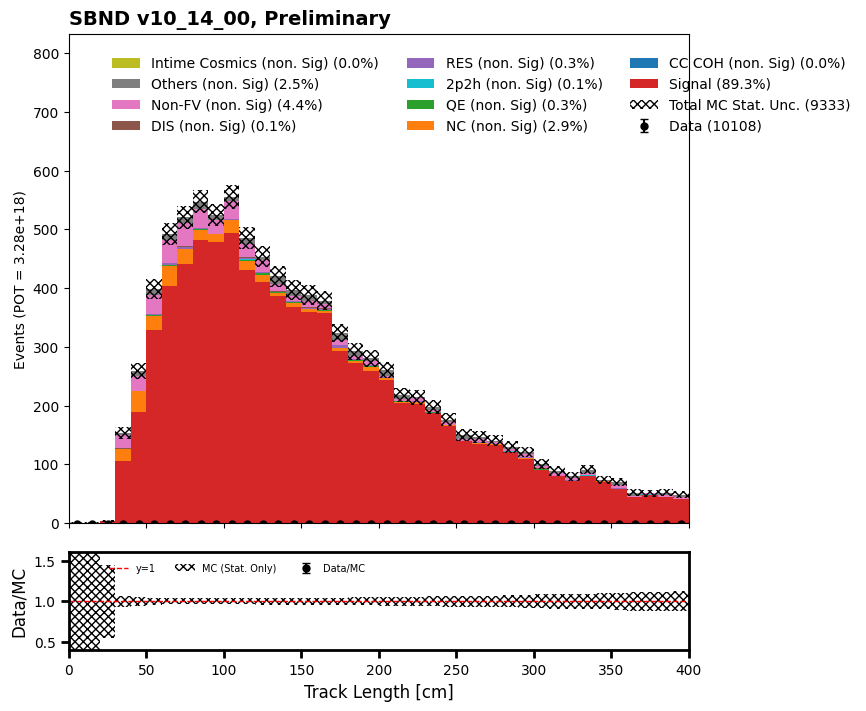

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


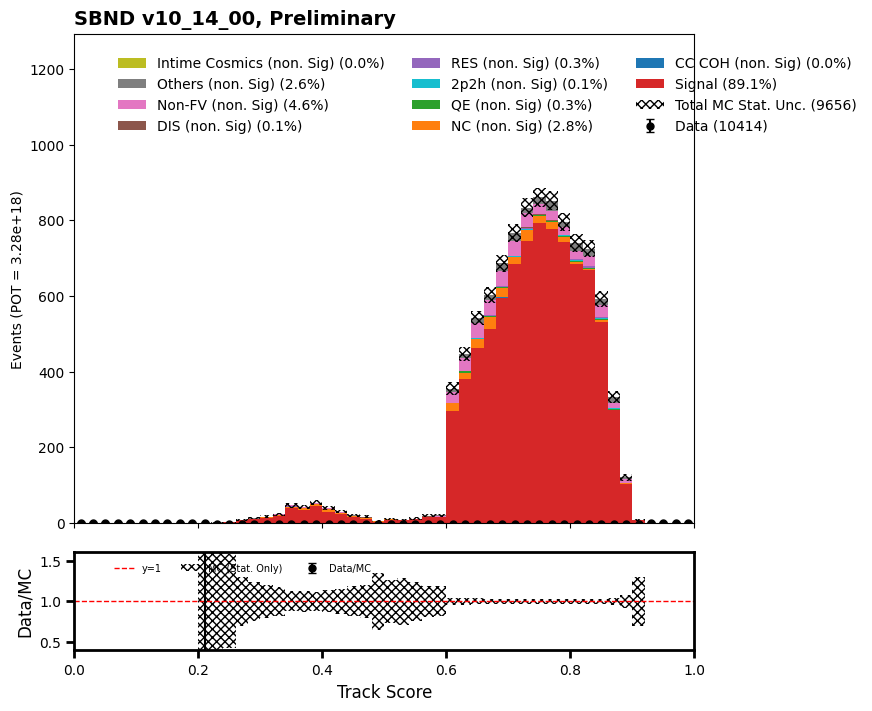

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

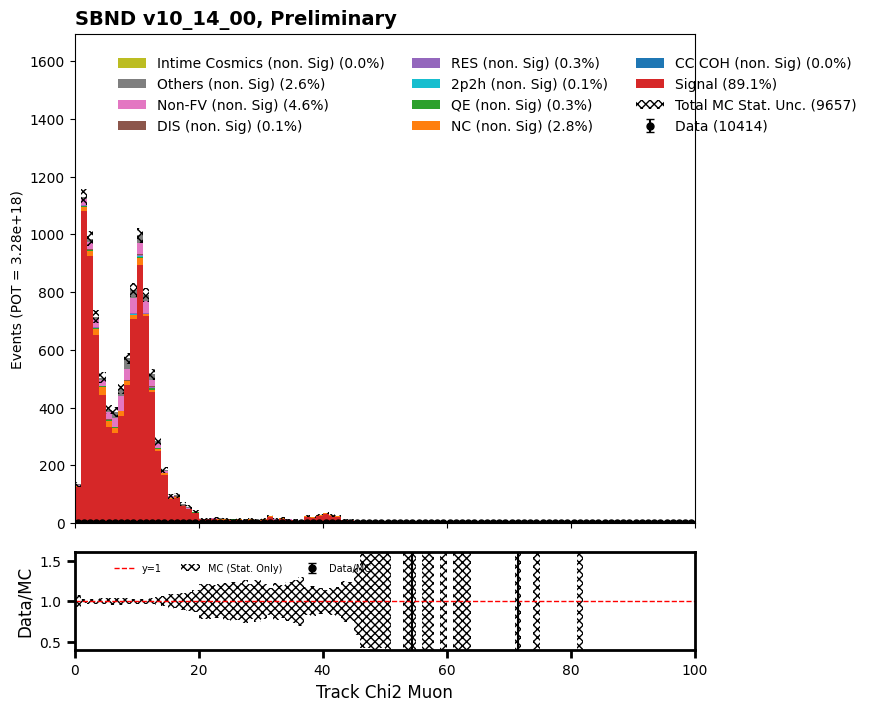

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

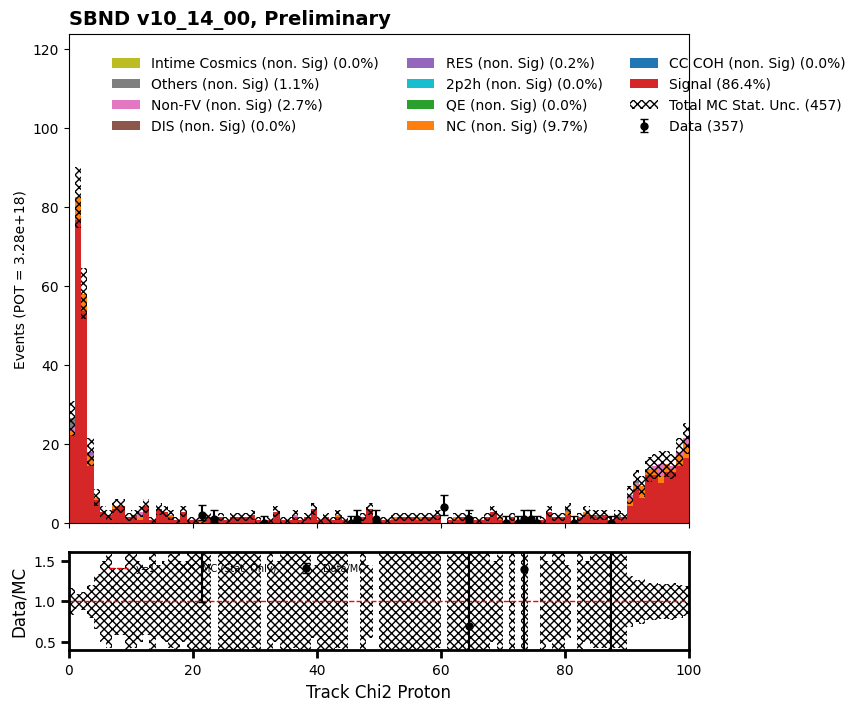

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = np.nan_to_num(data_eyhigh / total_mc, nan=0.)


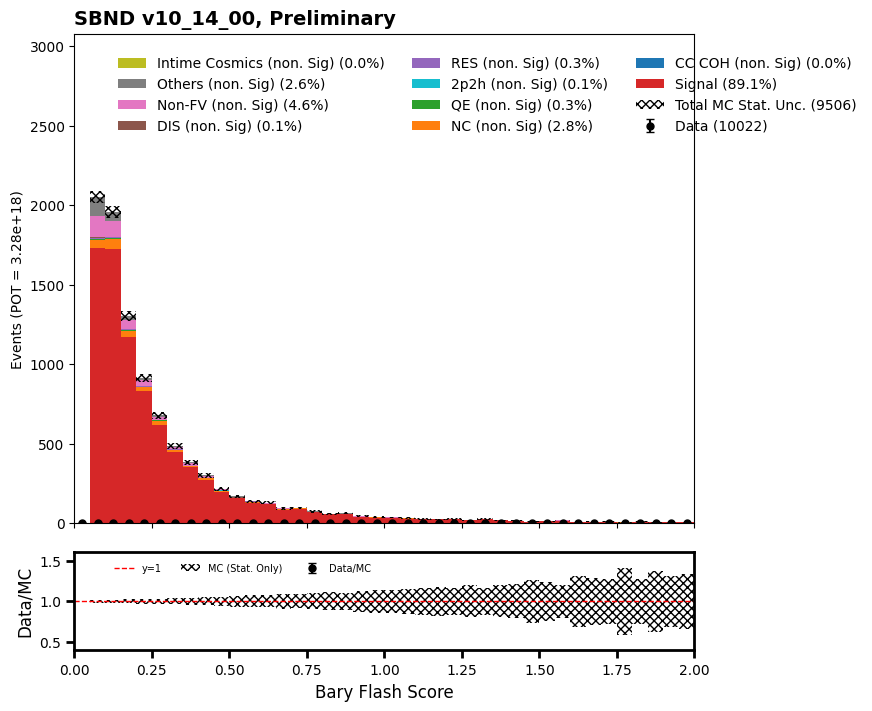

/tmp/ipykernel_1482/3738678688.py:74: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = np.nan_to_num(mc_stat_err / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:75: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = np.nan_to_num(total_mc / total_mc, nan=-999.)
/tmp/ipykernel_1482/3738678688.py:104: RuntimeWarning: invalid value encountered in divide
  signal_frac = np.nan_to_num(signal_mc / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:120: RuntimeWarning: invalid value encountered in divide
  data_ratio = np.nan_to_num(norm_counts / total_mc, nan=-1.)
/tmp/ipykernel_1482/3738678688.py:121: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_eylow / total_mc, nan=0.)
/tmp/ipykernel_1482/3738678688.py:122: RuntimeWarning: divide by zero

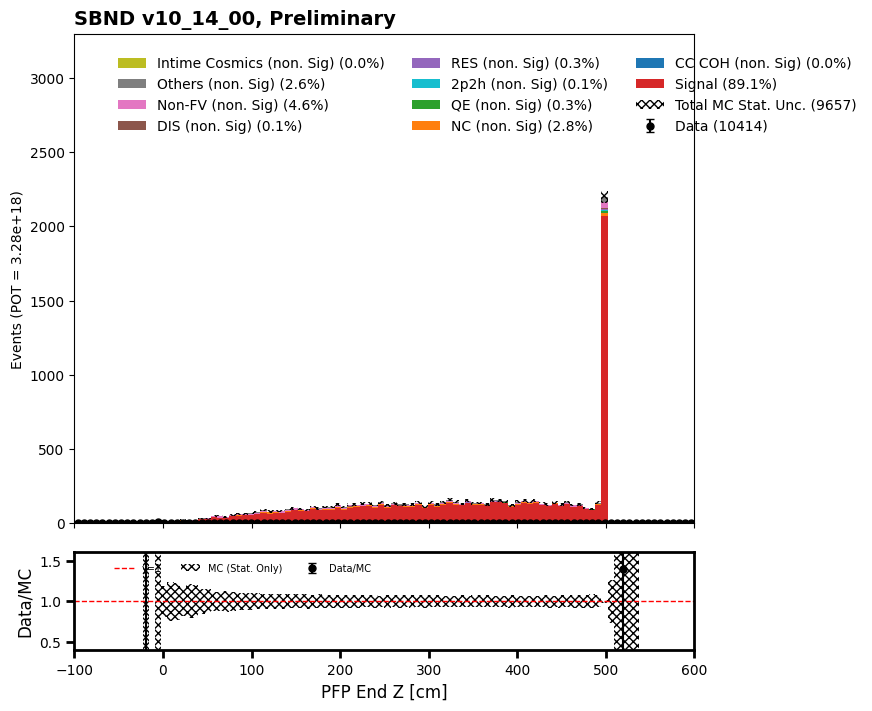

In [59]:
#muon candidates low z

#mc_bnb_cosmic_dfs["evt"] = mc_bnb_cosmic_dfs["evt"][HasMuonCandidate_lowZ(mc_bnb_cosmic_dfs["evt"])]
#data_offbeam_light_dfs["evt"] = data_offbeam_light_dfs["evt"][HasMuonCandidate_lowZ(data_offbeam_light_dfs["evt"])]
#data_bnb_light_dfs["evt"] = data_bnb_light_dfs["evt"][HasMuonCandidate_lowZ(data_bnb_light_dfs["evt"])]

#fractions_clear_cosmic_cosmiccut, fractions_nu_score_cosmiccut, fractions_vtx_x_cosmiccut, fractions_vtx_y_cosmiccut, fractions_vtx_z_cosmiccut, fractions_trk_len = draw_reco_valid_plots(mc_matchdf, data_evt_df, "nu_score")
draw_reco_valid_plots(mc_bnb_cosmic_dfs["evt"], data_offbeam_light_dfs["evt"], data_bnb_light_dfs["evt"], "a_vtx_fv_and_not_clear_cosmic_nu_score")

In [68]:
purity = 8605.1669921875/9656.748074412346
efficiency = 8605.1669921875/15446.2763671875
print("purity = ", round(purity*100,2), "% and efficiency = ", round(efficiency*100,2), "%")

purity =  89.11 % and efficiency =  55.71 %


In [93]:
#purity = number of true signal events selected / 
#          total number of events selected
#efficiency = number of true signal events selected / 
#             total number of true signal events